In [46]:
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark

import pandas as pd
import matplotlib.pyplot as plt
import json


desi_search_log_path = "data/local/hamann-objects-desi-search-log.json"
sdss_search_log_path = "data/local/hamann-objects-sdss-search-log.json"
hamann_desi_spectra_path = "data/local/hamann_desi_spectra.json"
hamann_sdss_spectra_path = "data/local/hamann_sdss_spectra.json"


settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False
    }

plt.rcParams.update(**settings)

In [26]:
desi_log = pd.read_json(desi_search_log_path)[["SDSS_id","best_match_id"]]
desi_log = desi_log.rename(columns={"best_match_id":"desi_match"})
desi_spectra = pd.read_json(hamann_desi_spectra_path)
desi_spectra["targetid"] = desi_spectra["targetid"].astype("string")
desi_spectra = desi_spectra.merge(desi_log,left_on="targetid",right_on="desi_match")

sdss_log = pd.read_json(sdss_search_log_path)[["SDSS_id","best_match_id"]]
sdss_log = sdss_log.rename(columns={"best_match_id":"boss_match"})
sdss_spectra = pd.read_json(hamann_sdss_spectra_path).merge(sdss_log,left_on="specid",right_on="boss_match")

spectra_combined = sdss_spectra.merge(desi_spectra,on="SDSS_id", suffixes=["_sdss","_desi"])

spectra_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   redshift_sdss          48 non-null     float64
 1   specid_sdss            48 non-null     int64  
 2   spectype_sdss          48 non-null     object 
 3   redshift_warning_sdss  48 non-null     int64  
 4   wavelength_sdss        48 non-null     object 
 5   flux_sdss              48 non-null     object 
 6   ivar_sdss              48 non-null     object 
 7   _dr_sdss               48 non-null     object 
 8   SDSS_id                48 non-null     object 
 9   boss_match             48 non-null     int64  
 10  redshift_desi          48 non-null     float64
 11  spectype_desi          48 non-null     object 
 12  targetid               48 non-null     object 
 13  specid_desi            48 non-null     int64  
 14  redshift_warning_desi  48 non-null     int64  
 15  waveleng

---------------------------------------
---------------------------------------

SDSS: J130936.14+560111.3


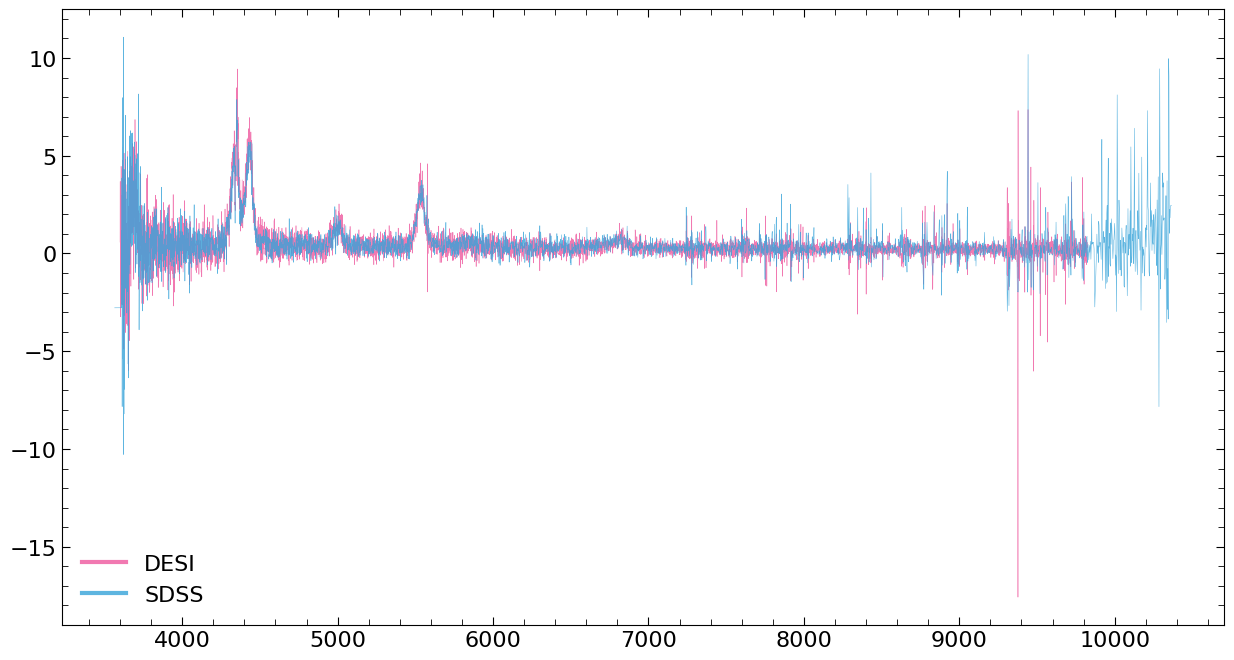

---------------------------------------
---------------------------------------

SDSS: J005044.95-021217.6


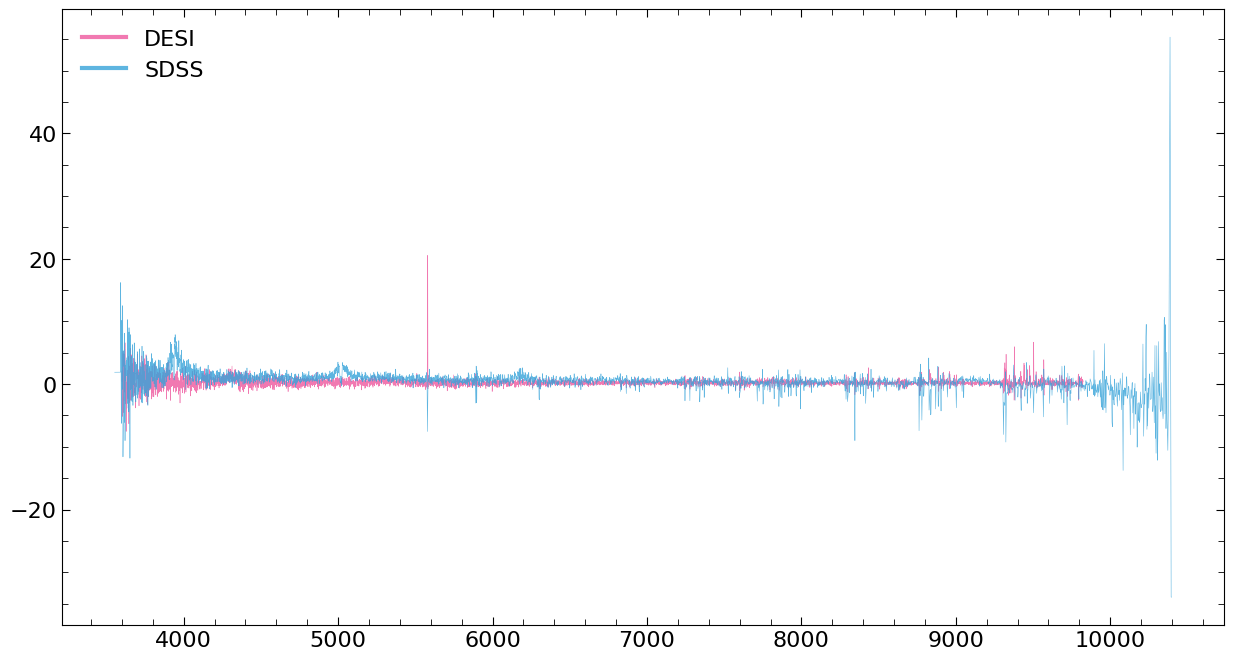

---------------------------------------
---------------------------------------

SDSS: J020932.15+312202.7


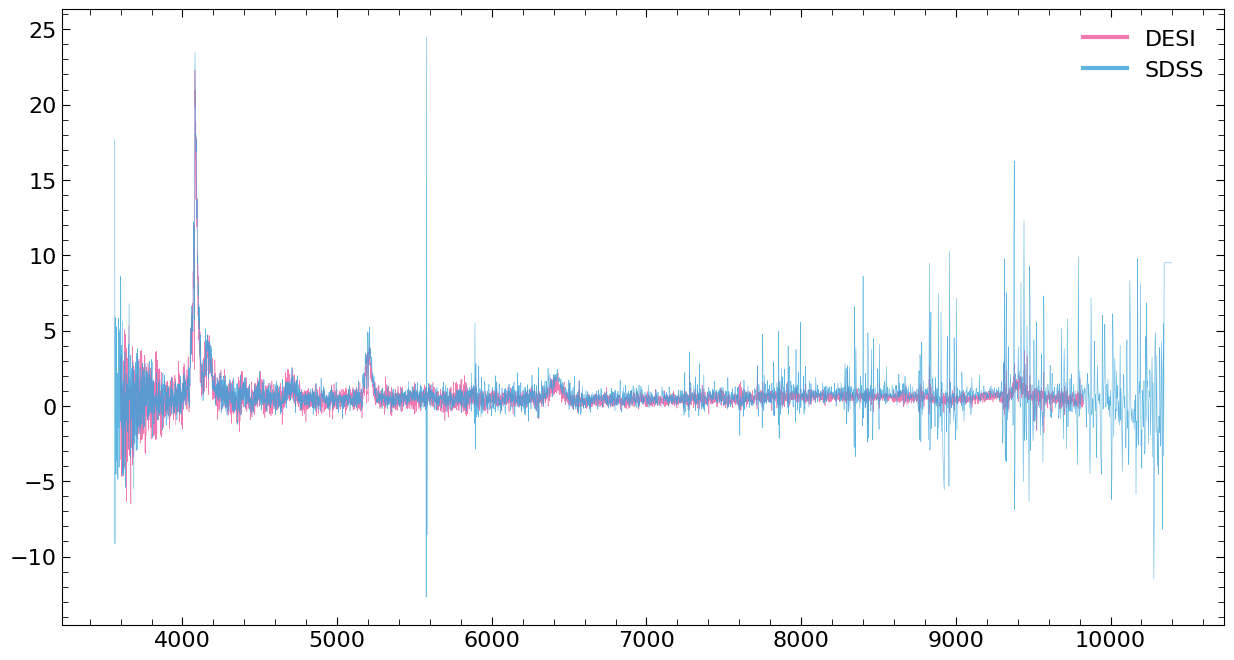

---------------------------------------
---------------------------------------

SDSS: J014111.13-031852.5


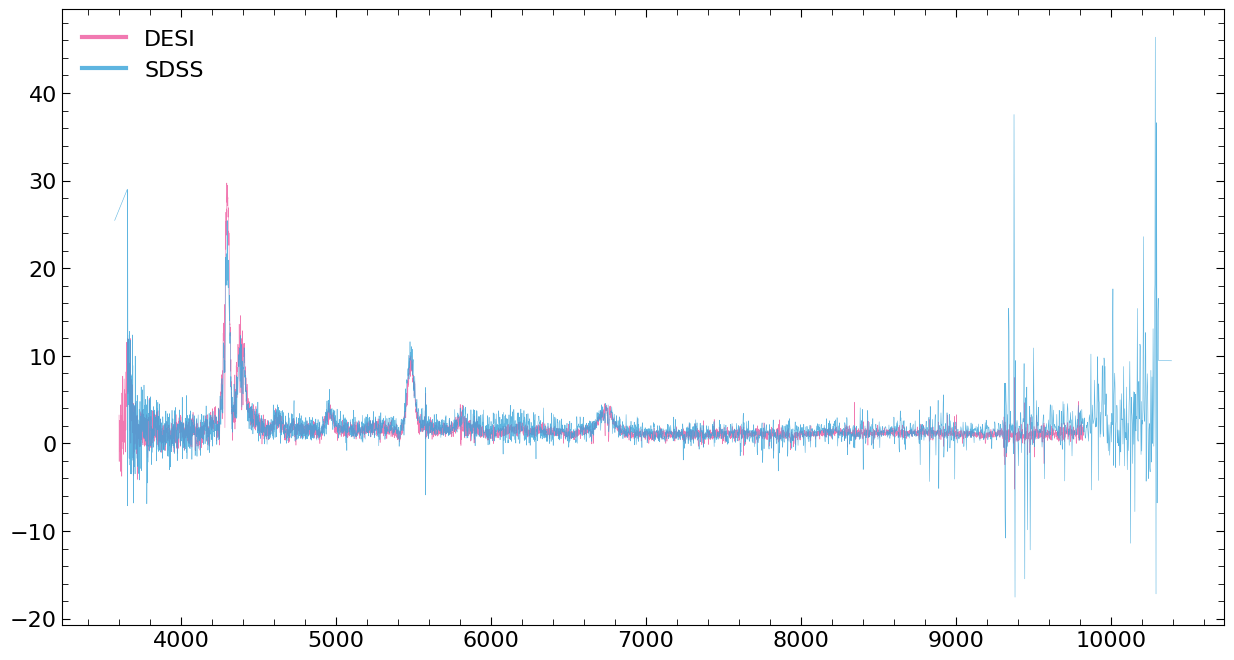

---------------------------------------
---------------------------------------

SDSS: J002400.25+245031.9


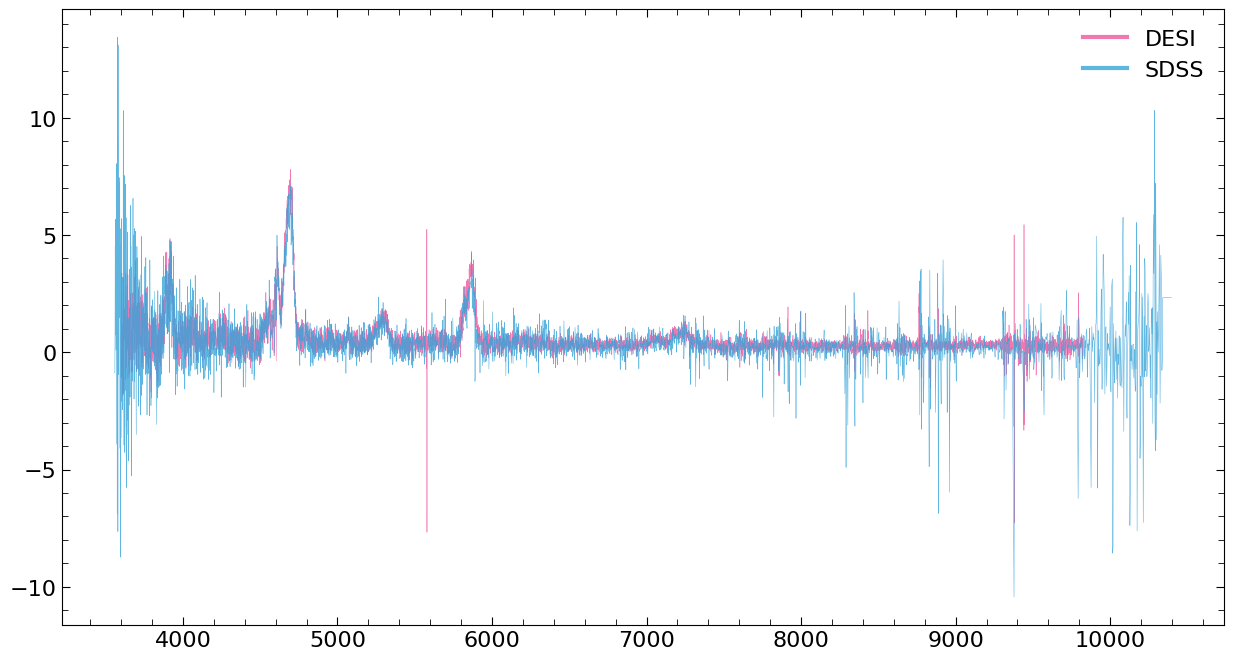

---------------------------------------
---------------------------------------

SDSS: J110202.68-000752.7


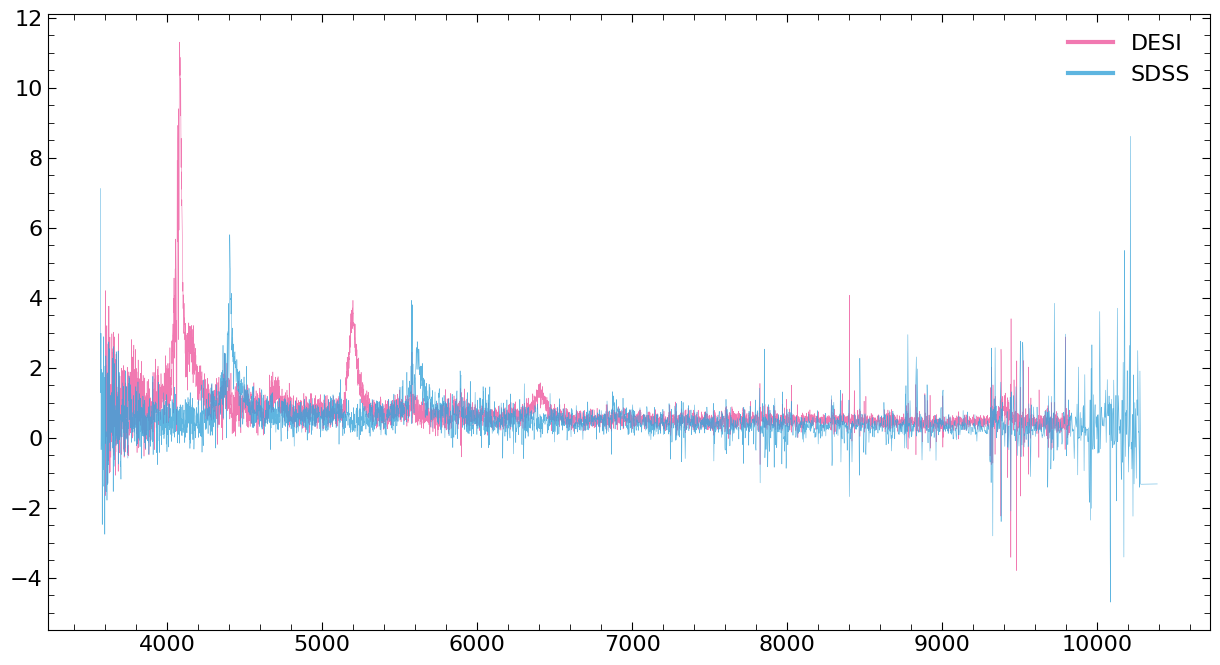

---------------------------------------
---------------------------------------

SDSS: J160431.55+563354.2


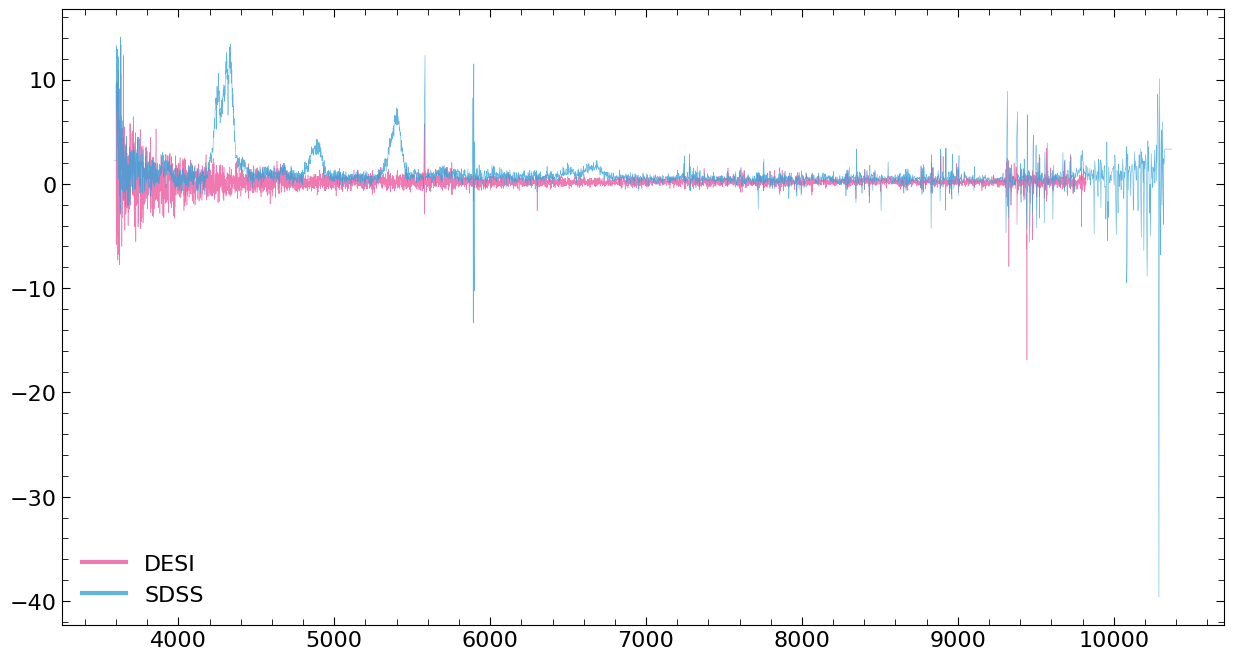

---------------------------------------
---------------------------------------

SDSS: J083448.48+015921.1


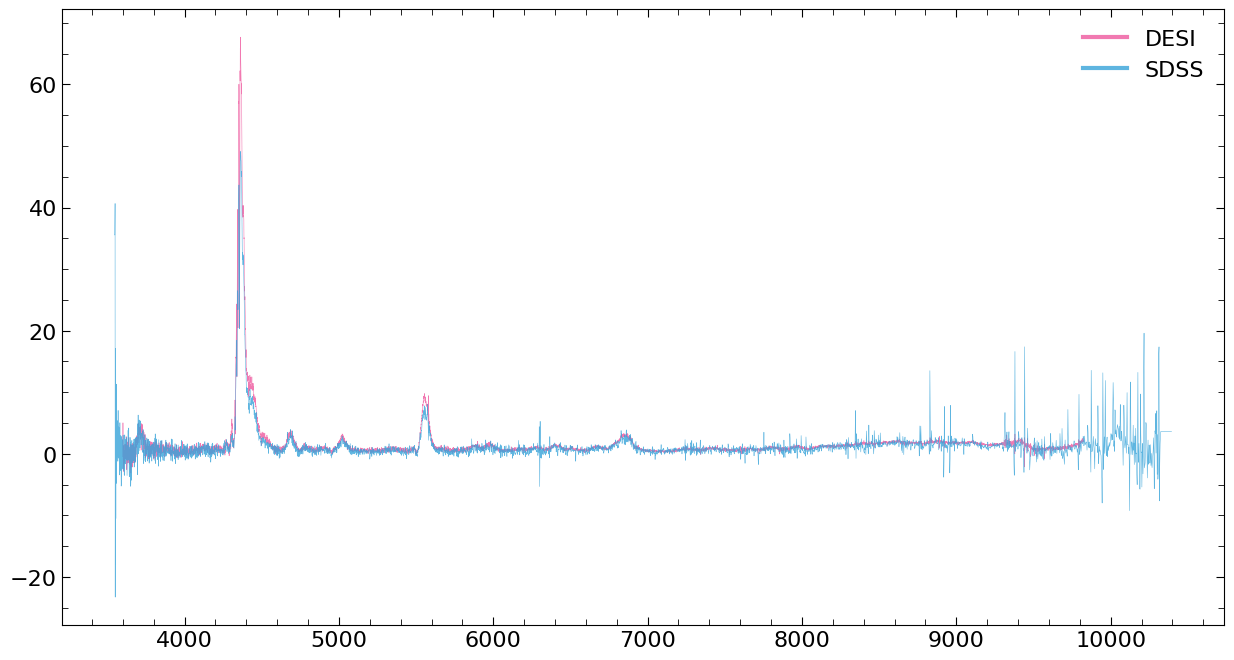

---------------------------------------
---------------------------------------

SDSS: J223754.52+065026.6


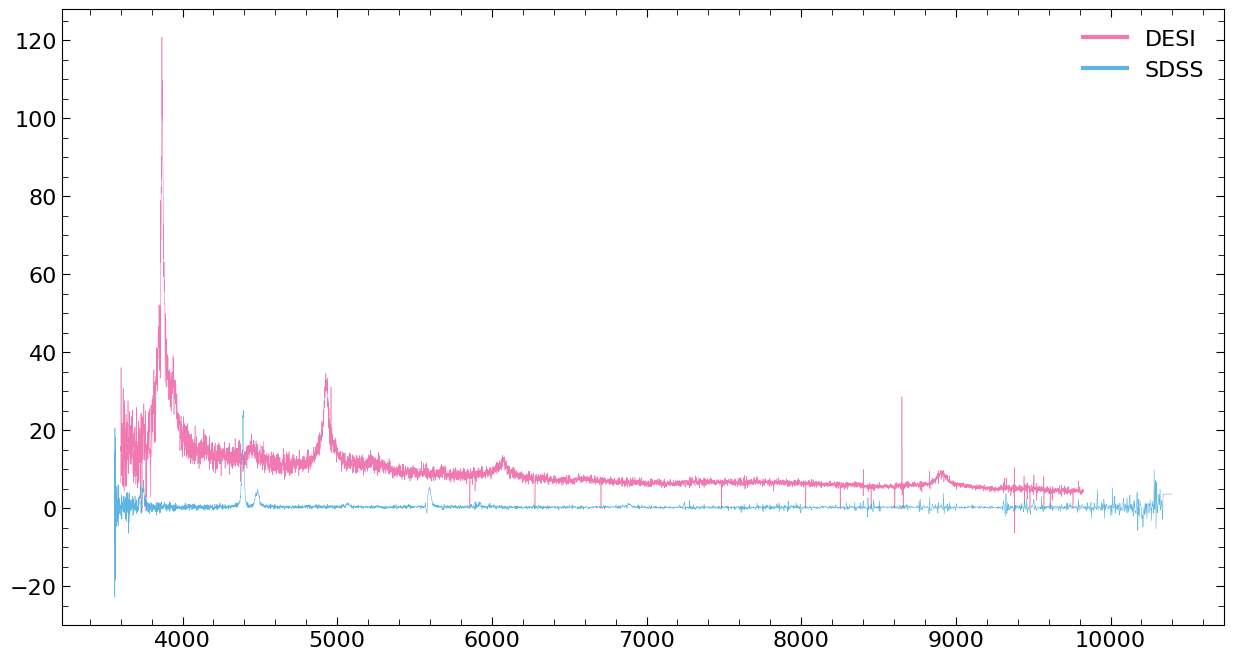

---------------------------------------
---------------------------------------

SDSS: J085451.11+173009.1


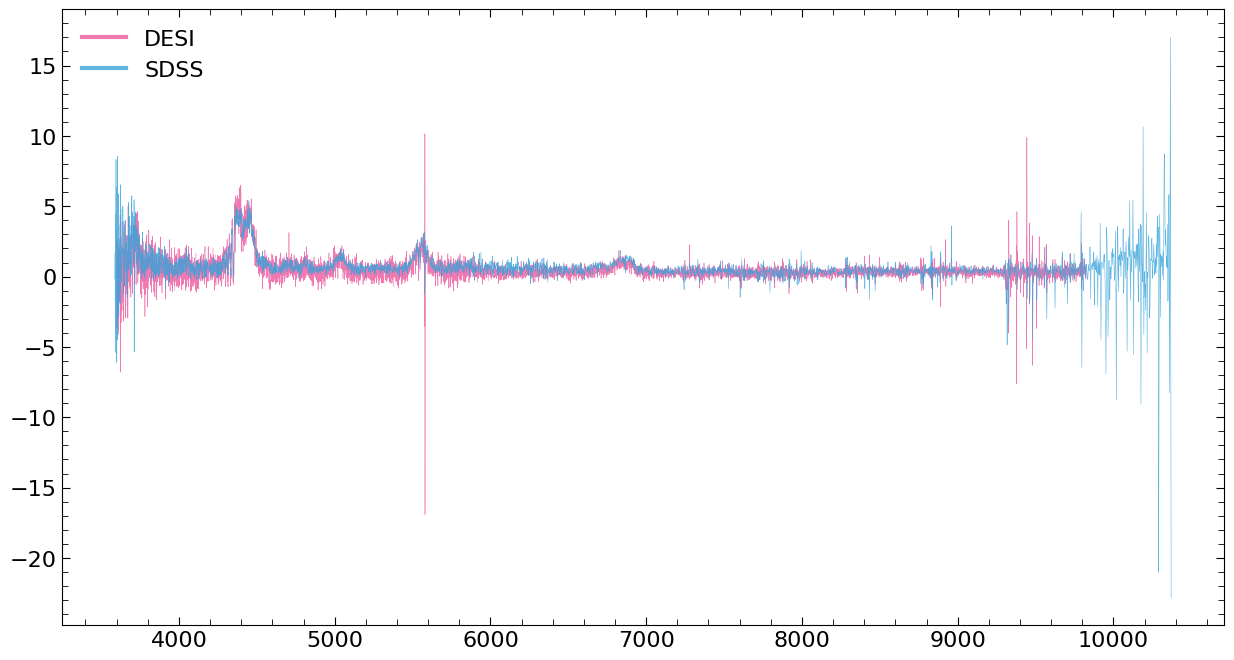

---------------------------------------
---------------------------------------

SDSS: J104611.50+024351.6


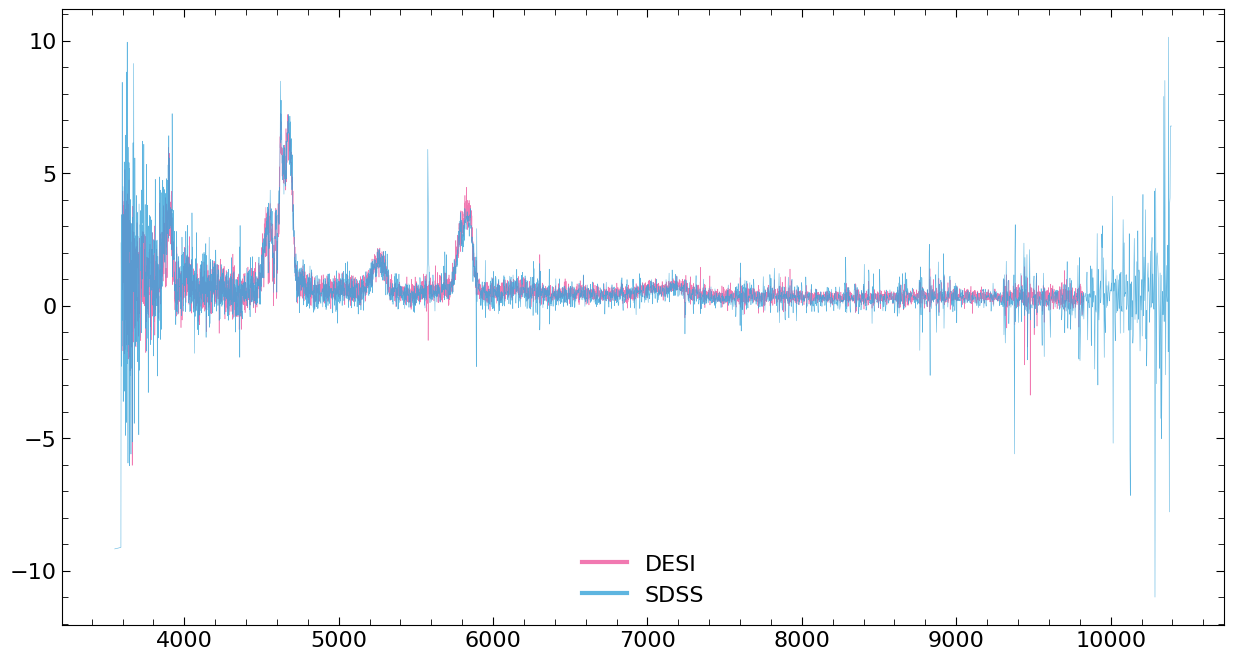

---------------------------------------
---------------------------------------

SDSS: J134417.34+445459.4


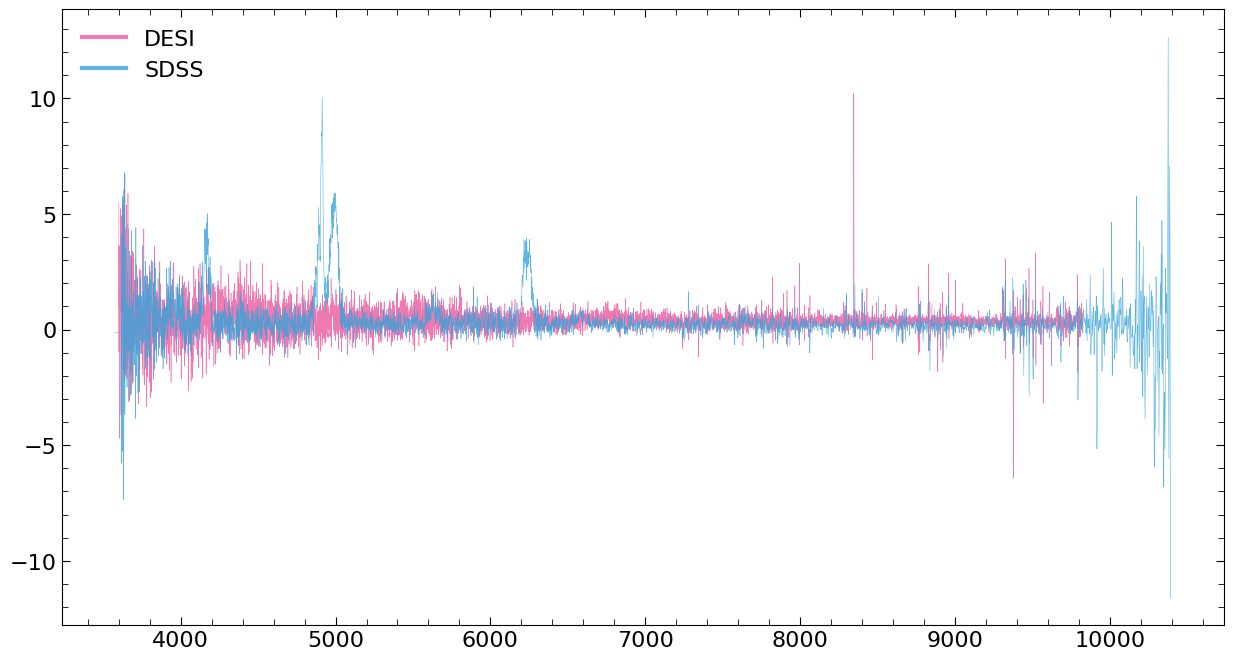

---------------------------------------
---------------------------------------

SDSS: J125019.46+630638.6


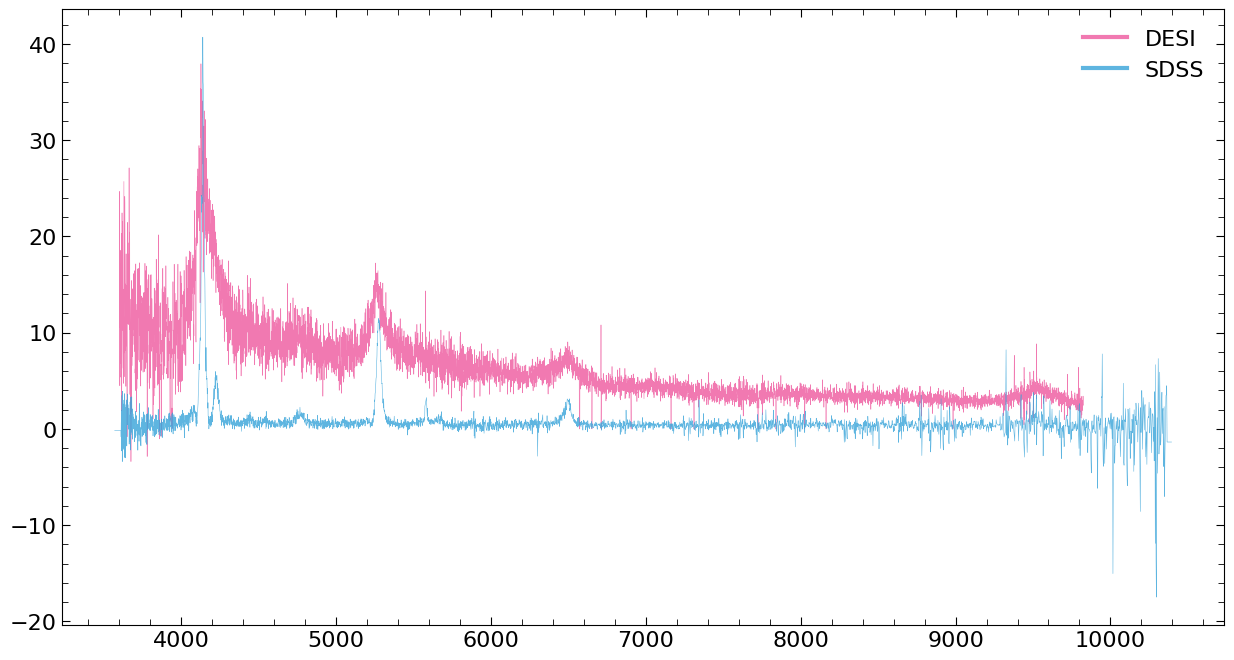

---------------------------------------
---------------------------------------

SDSS: J131047.78+322518.3


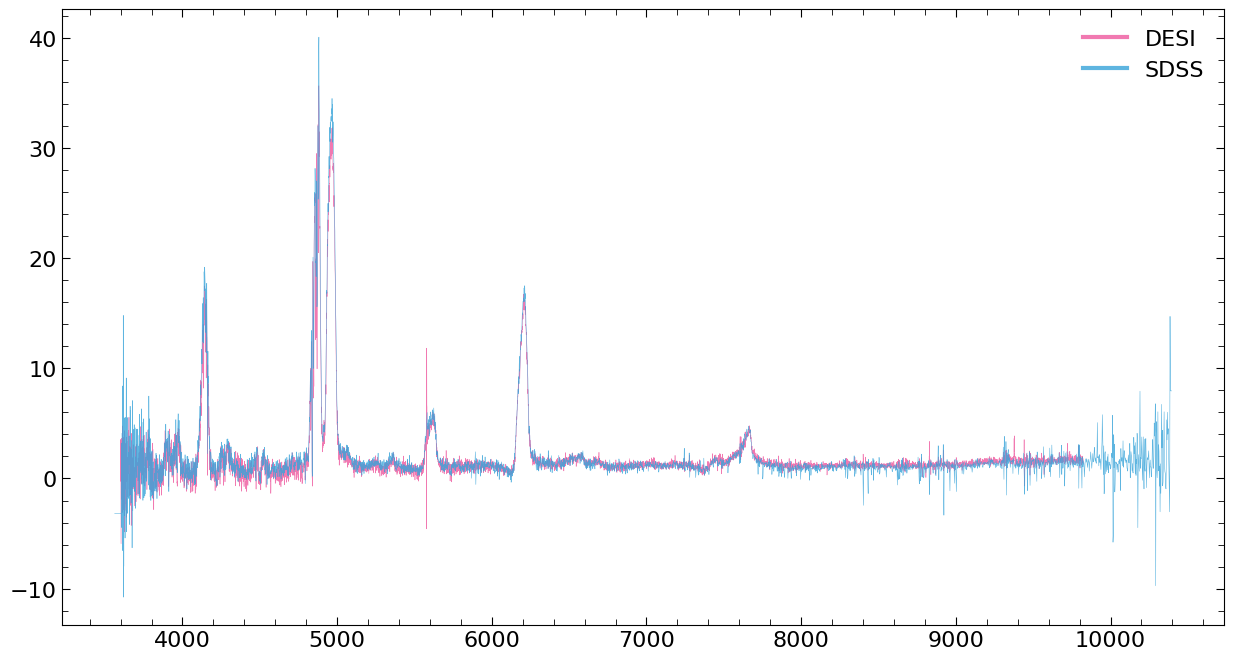

---------------------------------------
---------------------------------------

SDSS: J082653.42+054247.3


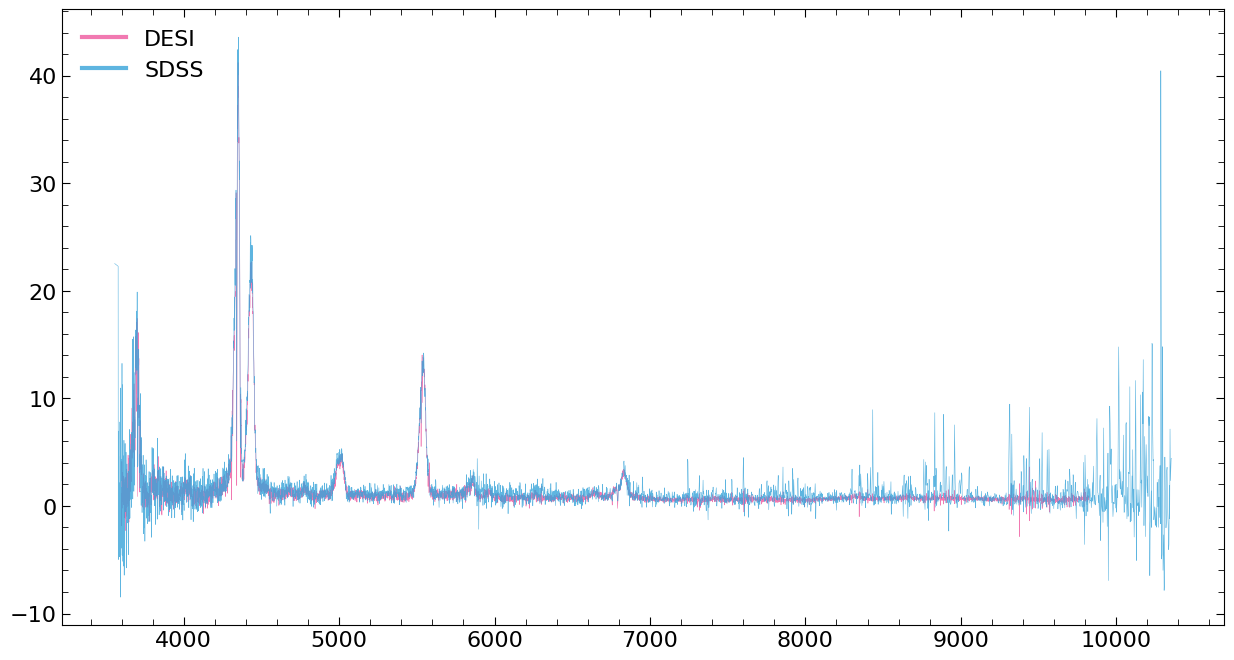

---------------------------------------
---------------------------------------

SDSS: J102447.32-013633.8


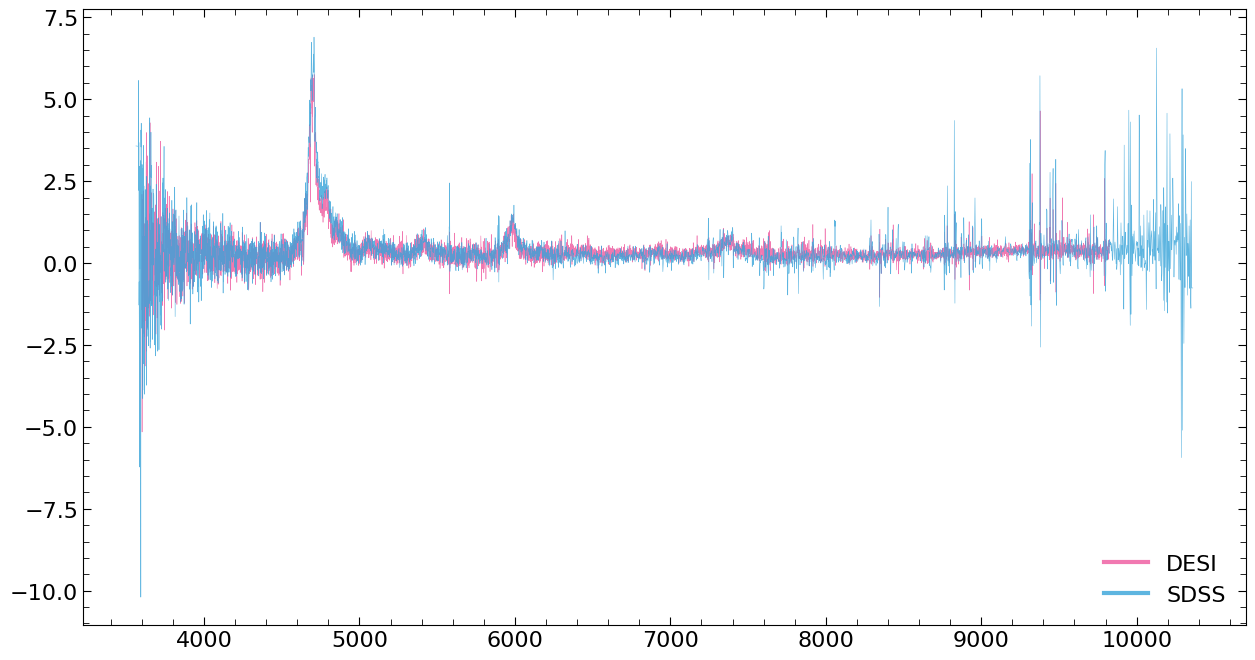

---------------------------------------
---------------------------------------

SDSS: J134001.90+322155.9


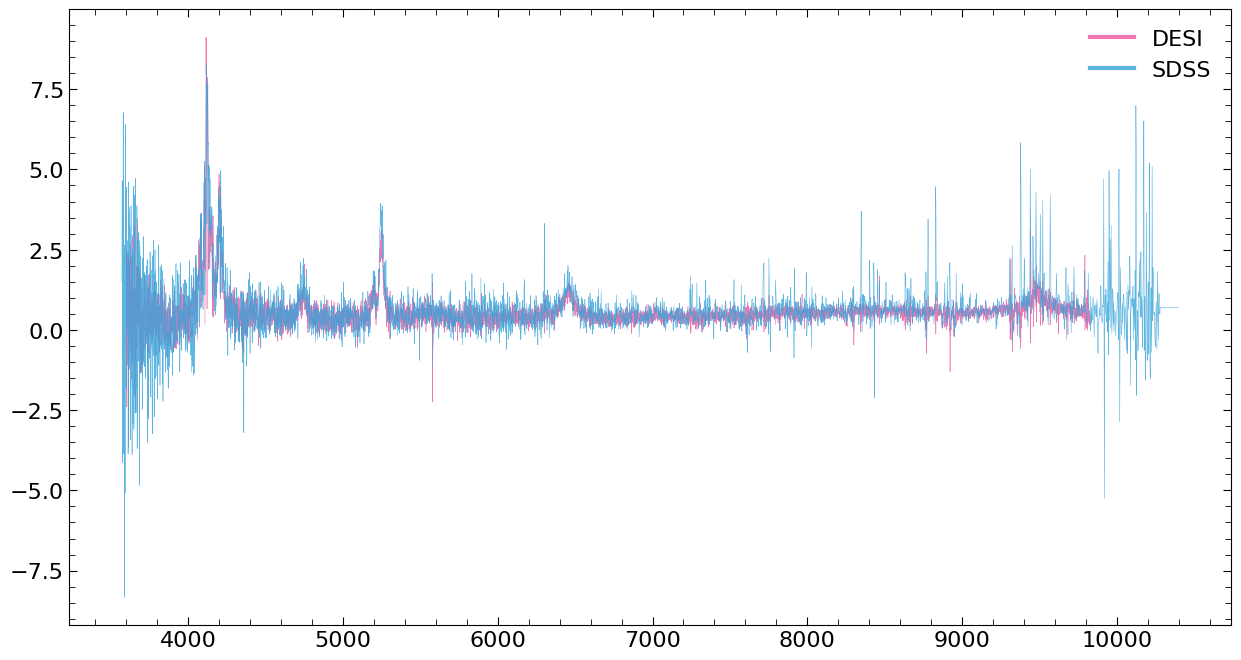

---------------------------------------
---------------------------------------

SDSS: J222421.63+174041.2


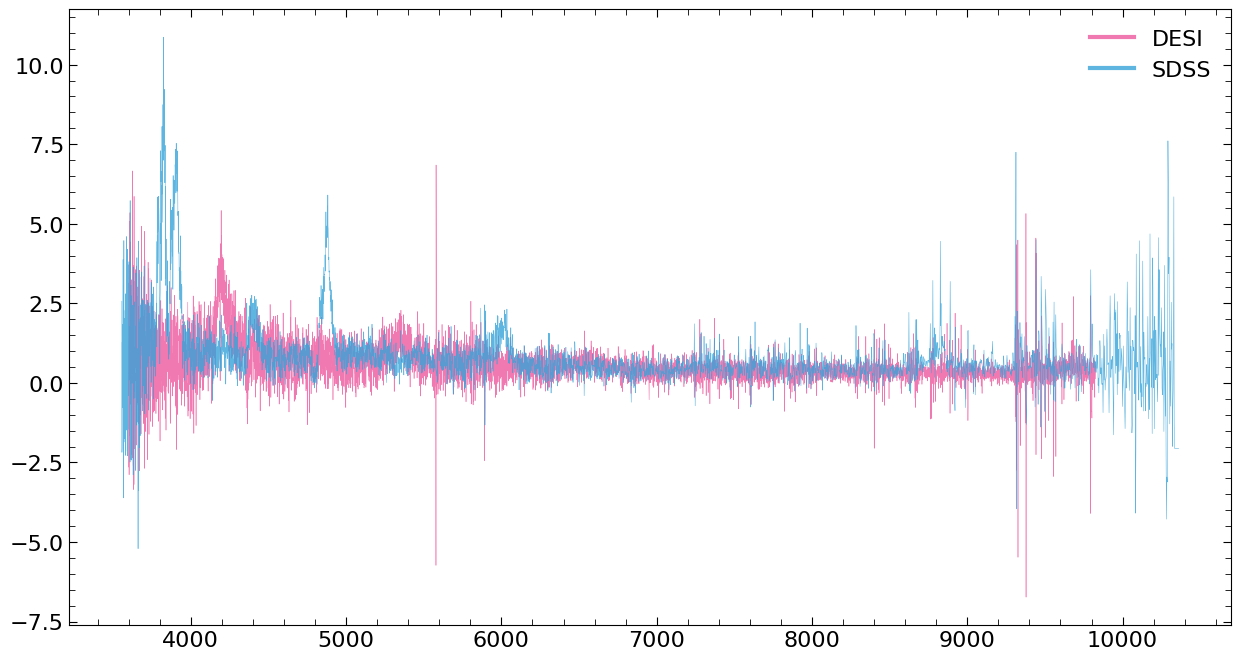

---------------------------------------
---------------------------------------

SDSS: J134450.51+140139.2


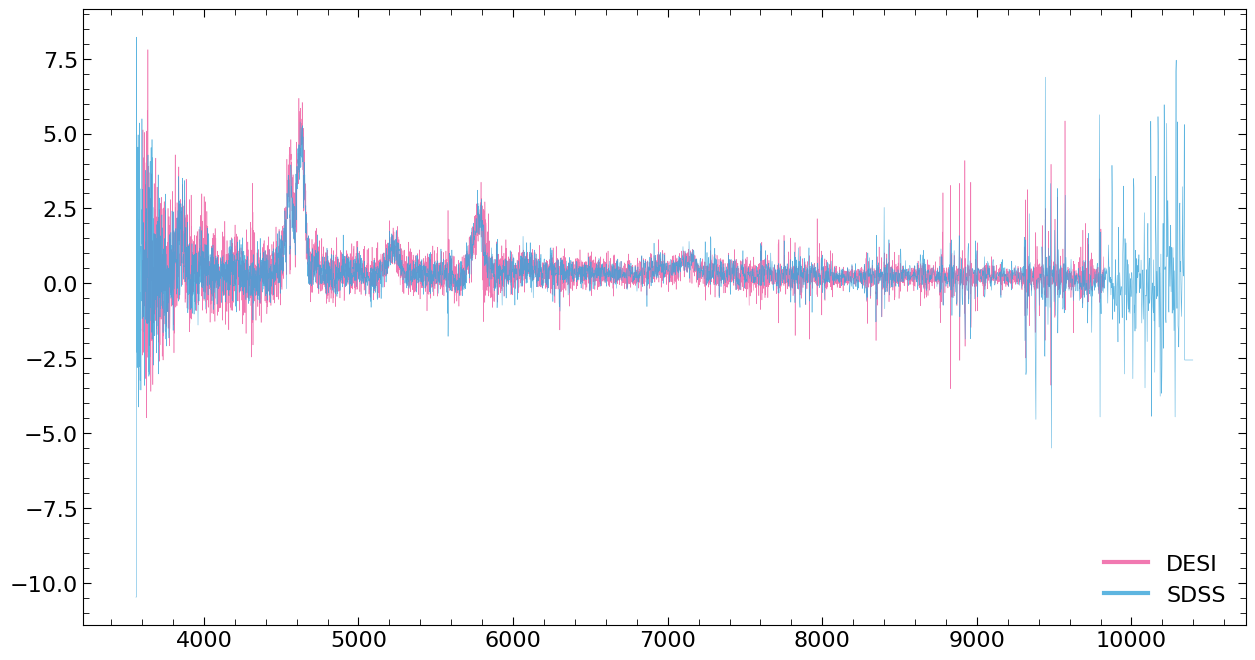

---------------------------------------
---------------------------------------

SDSS: J232828.47+044346.8


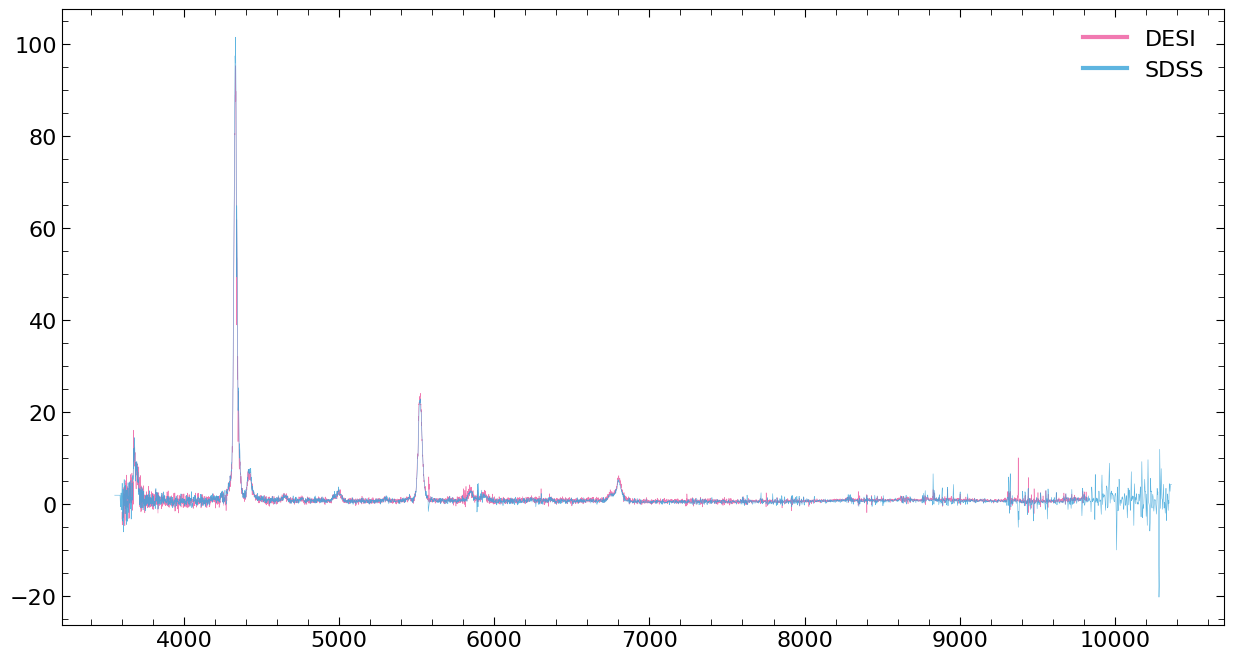

---------------------------------------
---------------------------------------

SDSS: J082649.30+163945.2


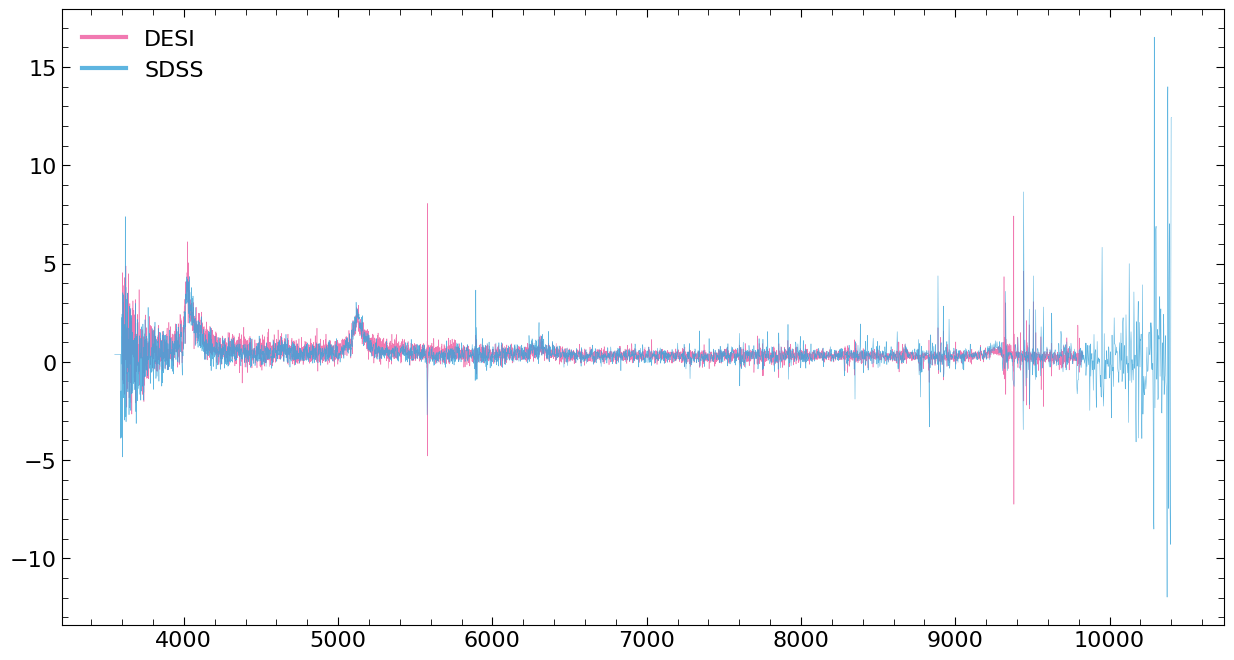

---------------------------------------
---------------------------------------

SDSS: J111355.72+451452.6


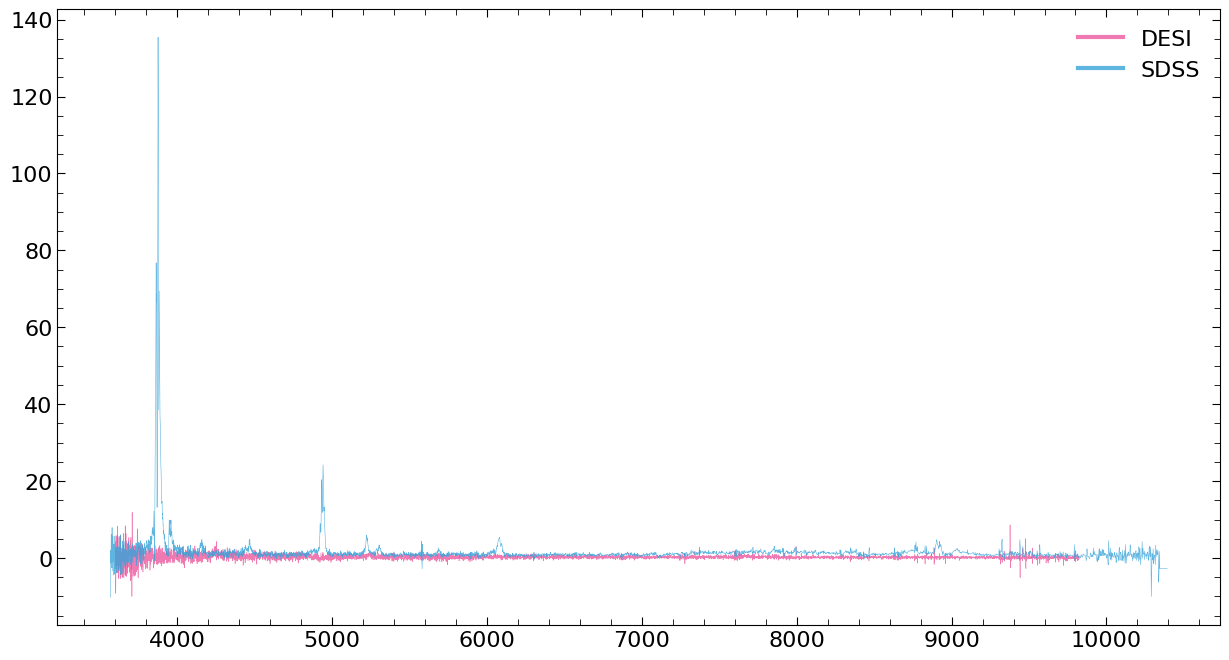

---------------------------------------
---------------------------------------

SDSS: J103146.53+290324.1


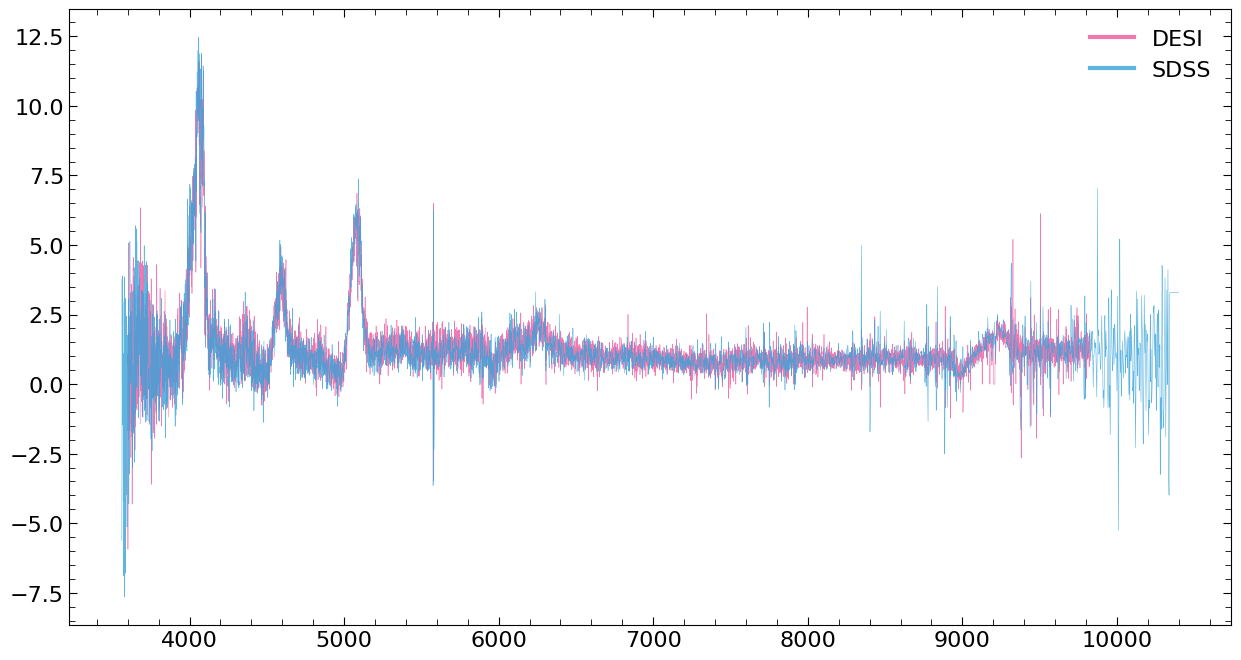

---------------------------------------
---------------------------------------

SDSS: J005233.24-055653.5


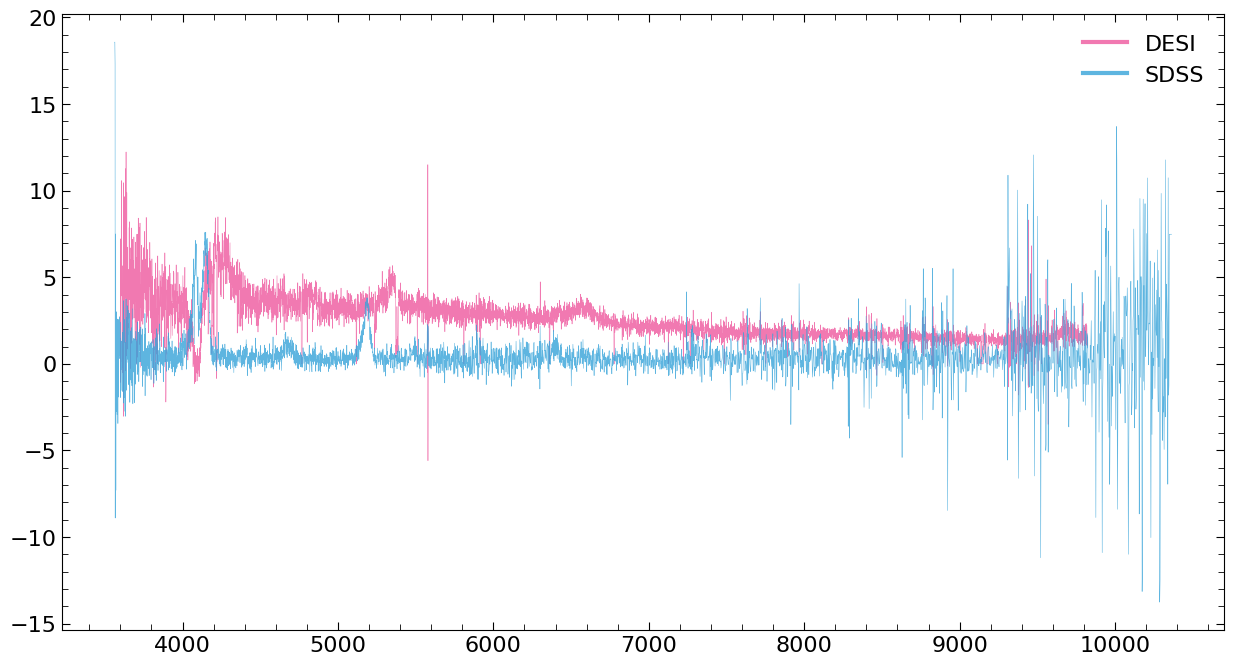

---------------------------------------
---------------------------------------

SDSS: J082536.31+200040.3


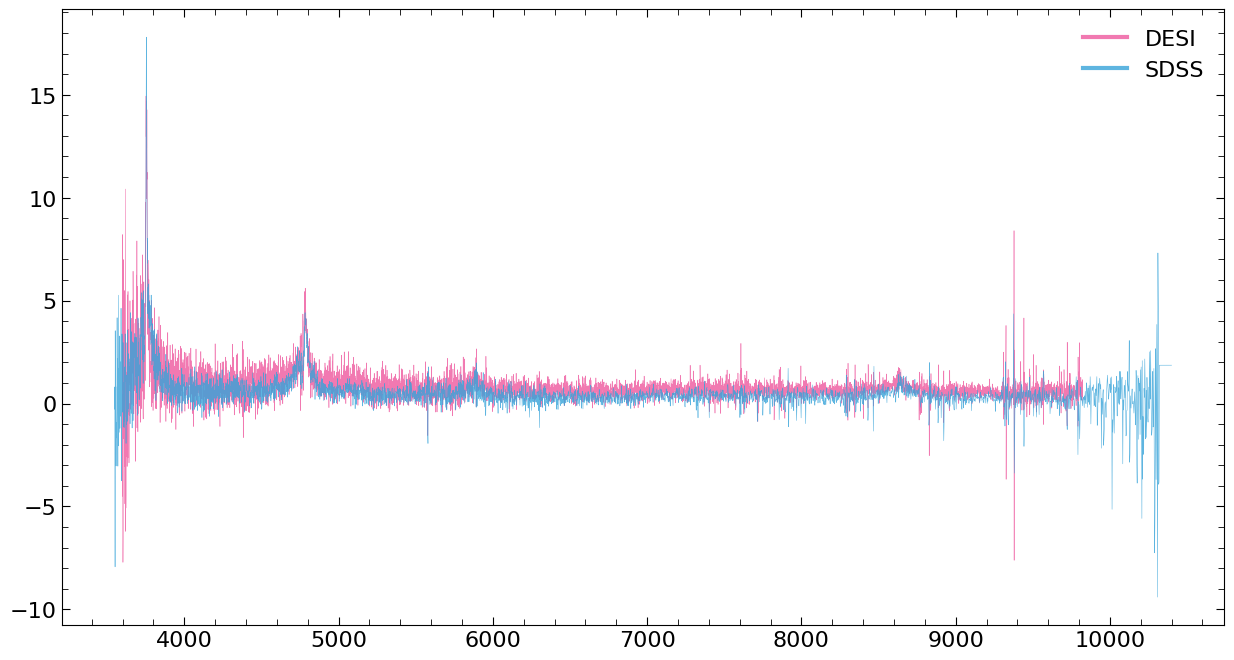

---------------------------------------
---------------------------------------

SDSS: J134026.99+083427.2


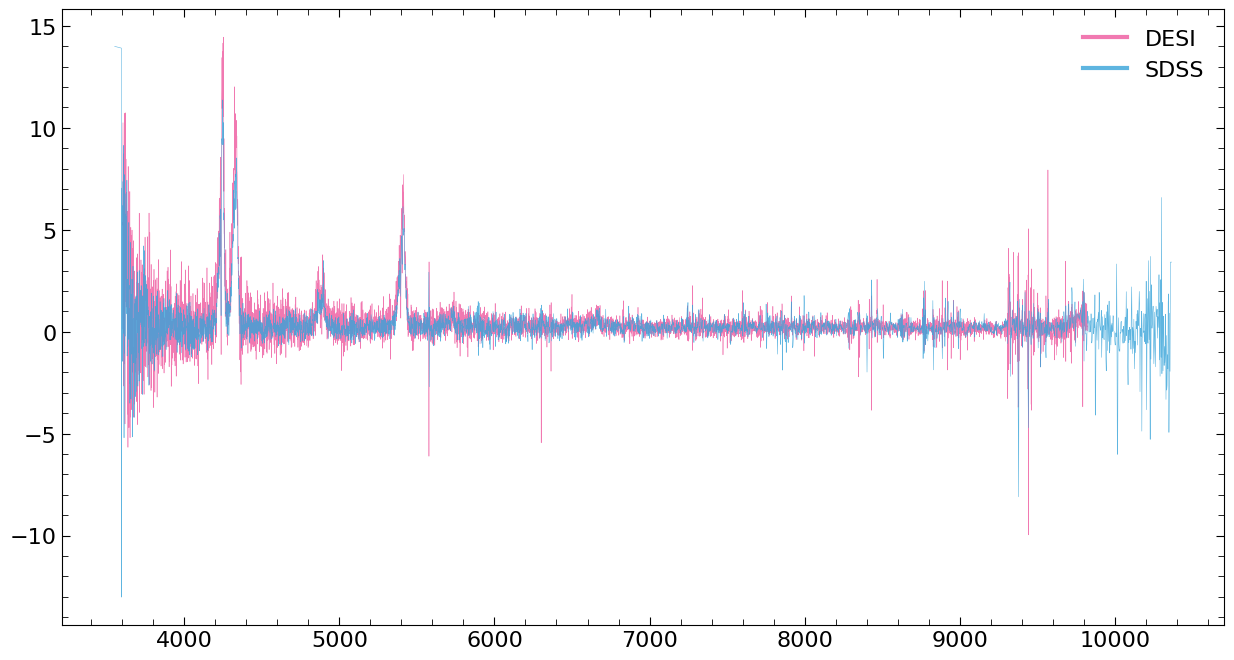

---------------------------------------
---------------------------------------

SDSS: J122000.68+064045.3


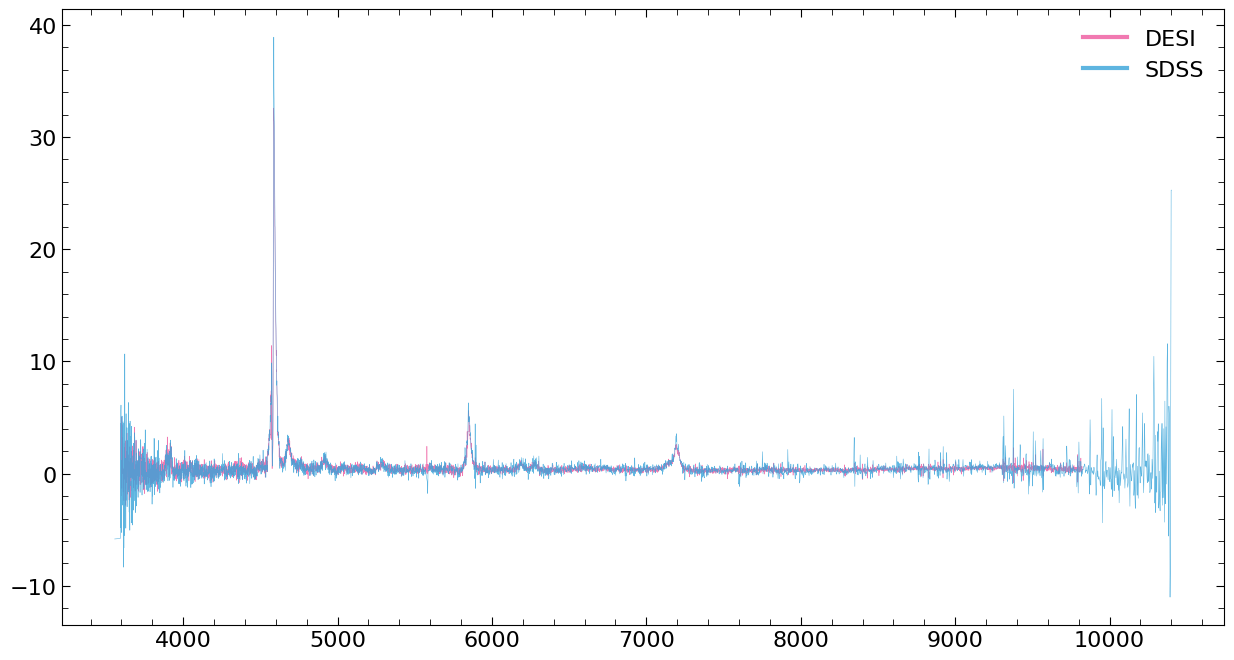

---------------------------------------
---------------------------------------

SDSS: J093506.96-024137.7


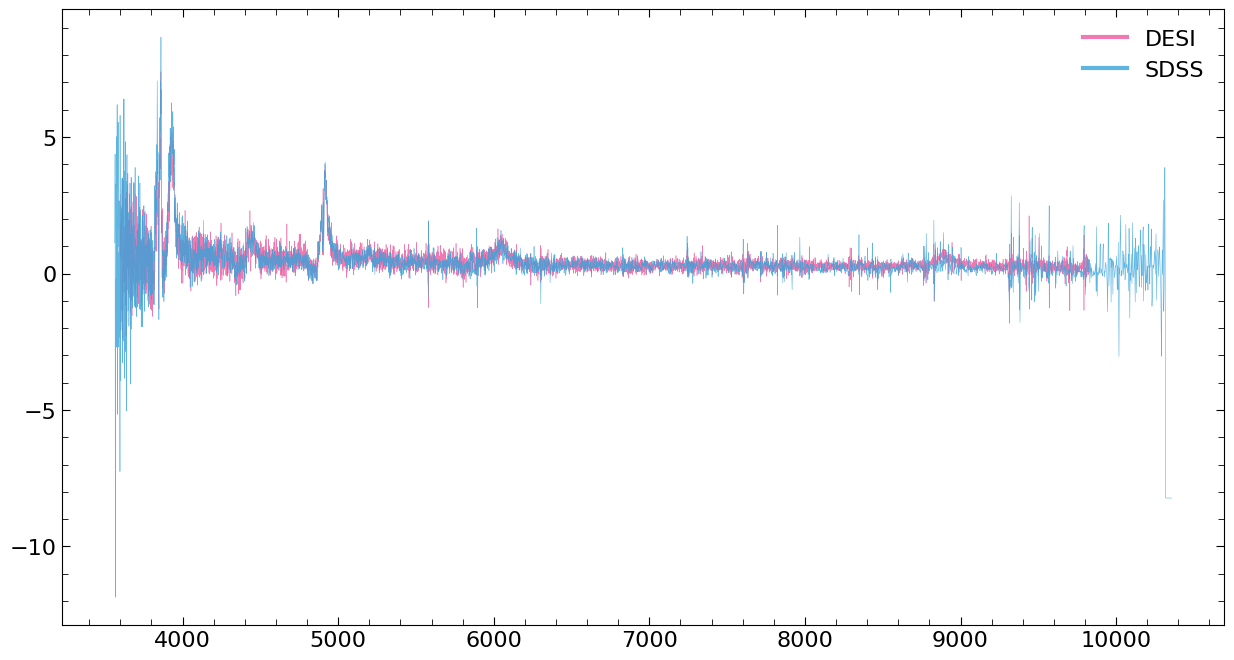

---------------------------------------
---------------------------------------

SDSS: J080547.66+454159.0


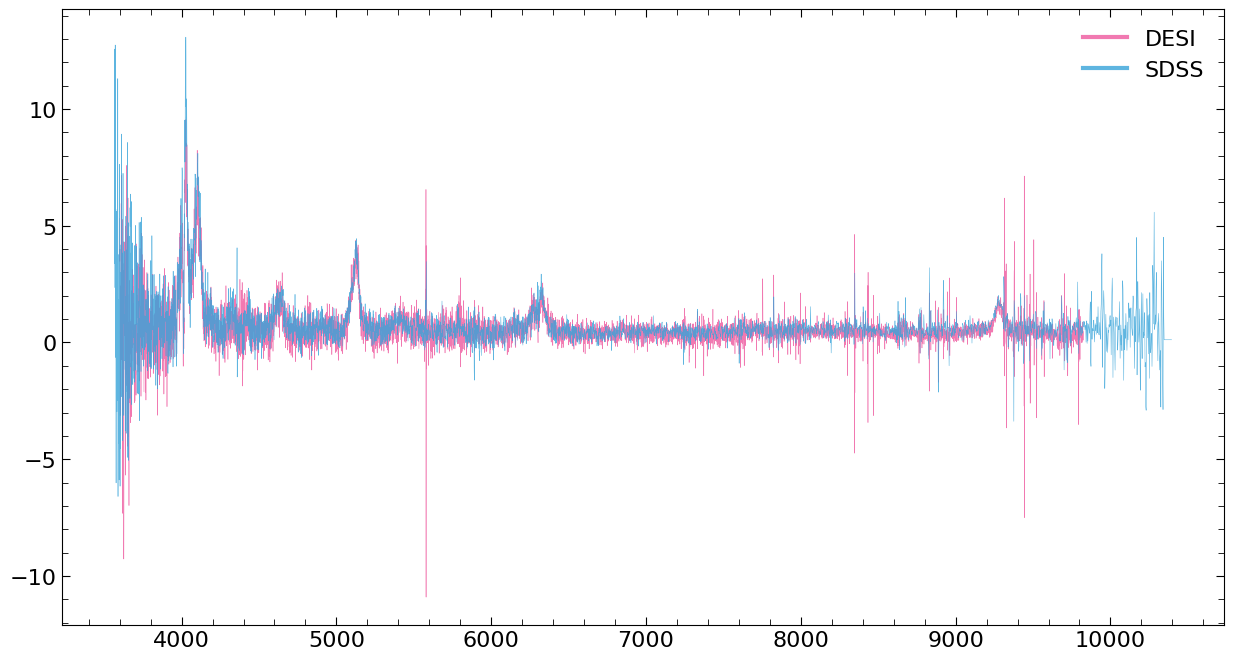

---------------------------------------
---------------------------------------

SDSS: J091508.45+561316.0


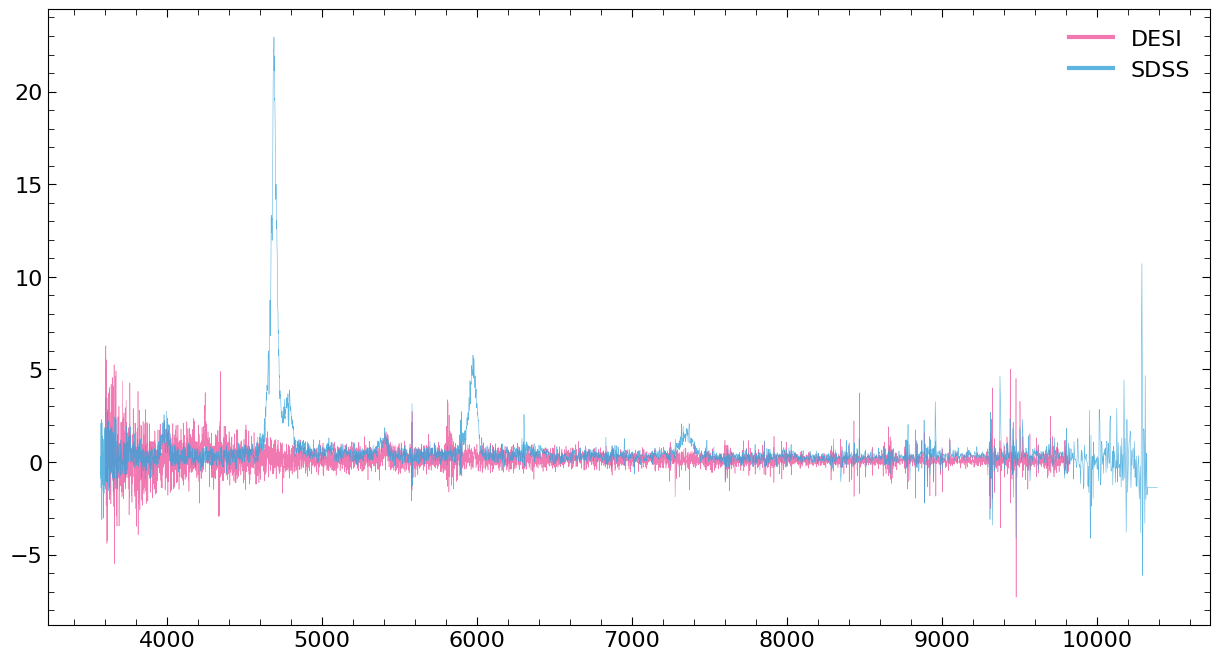

---------------------------------------
---------------------------------------

SDSS: J121704.70+023417.1


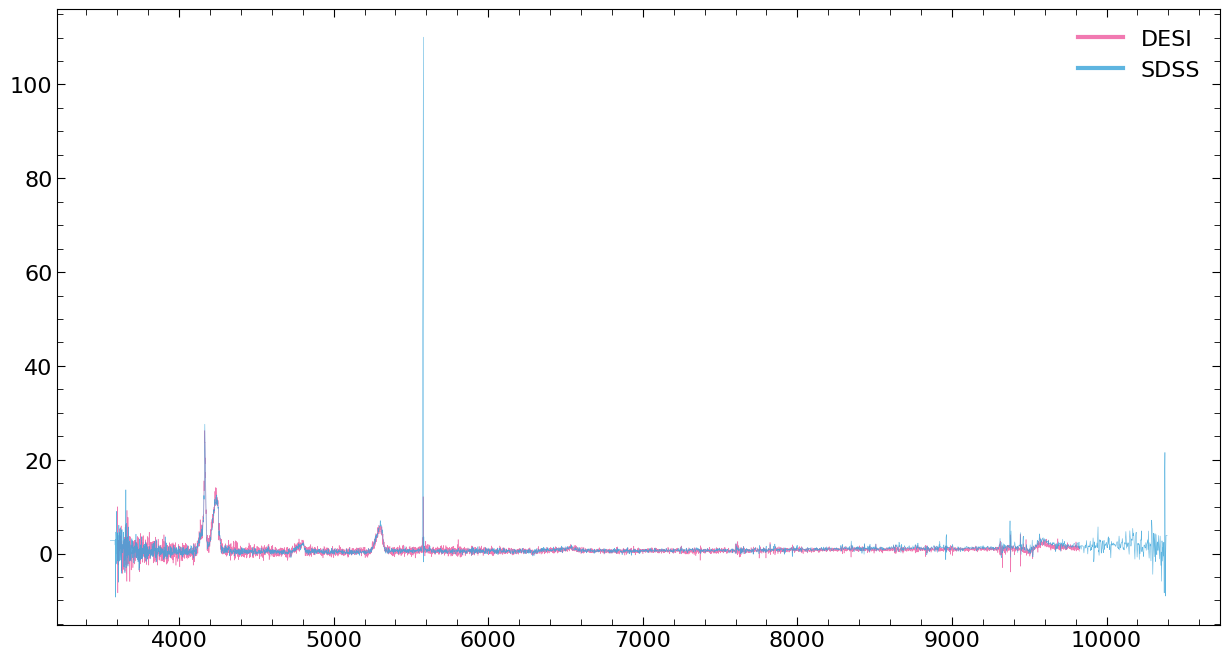

---------------------------------------
---------------------------------------

SDSS: J153108.10+213725.1


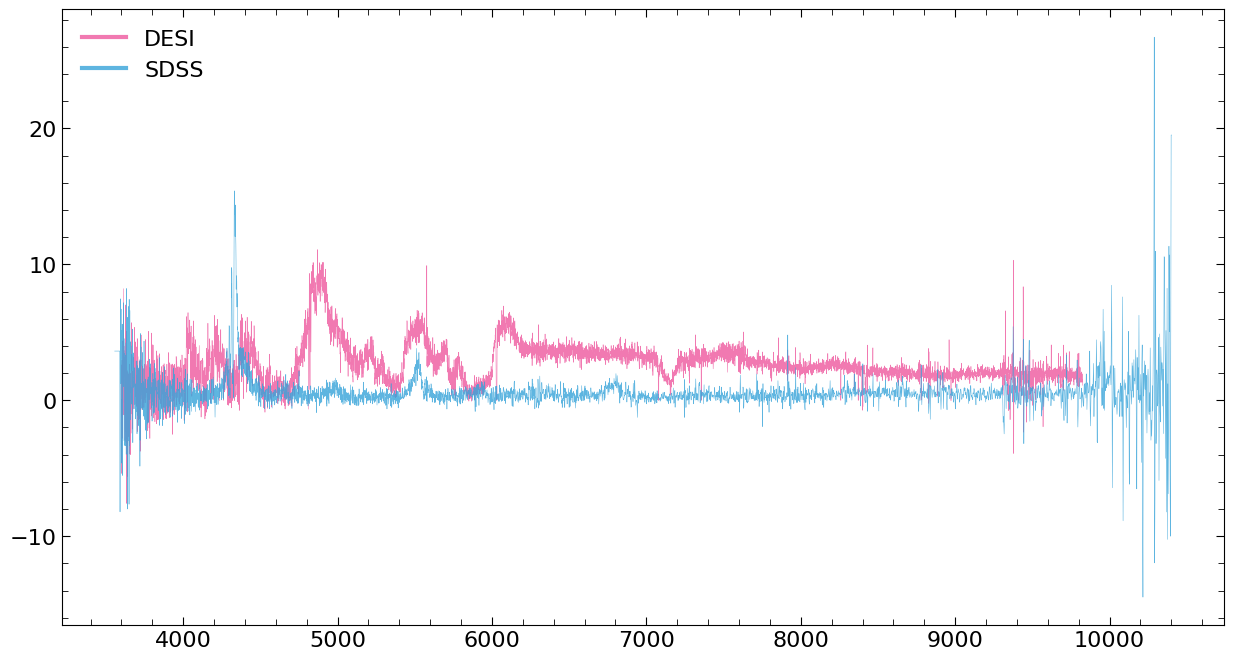

---------------------------------------
---------------------------------------

SDSS: J233636.99+065231.0


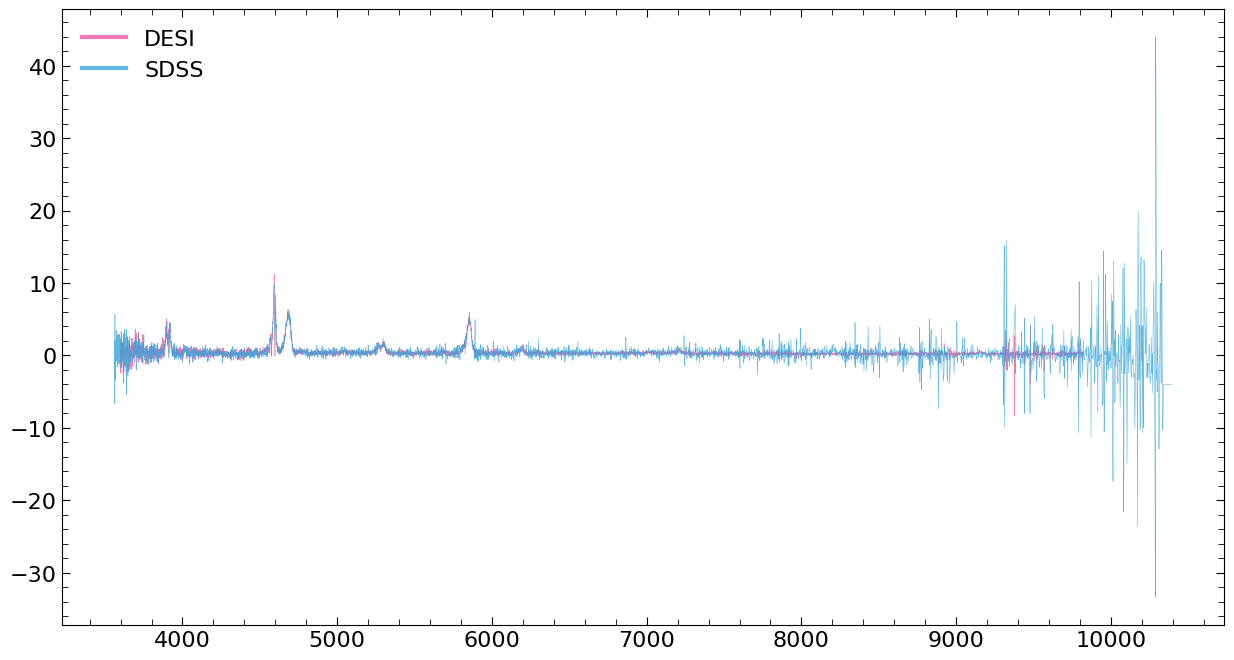

---------------------------------------
---------------------------------------

SDSS: J154831.92+311951.4


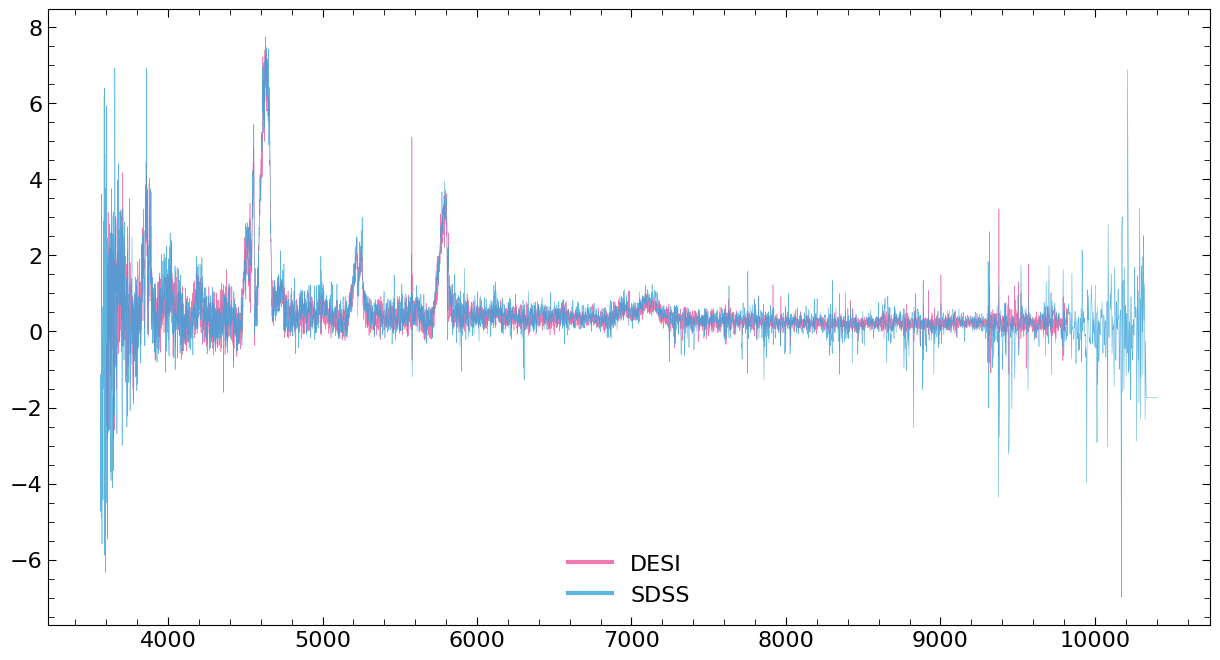

---------------------------------------
---------------------------------------

SDSS: J165202.64+172852.3


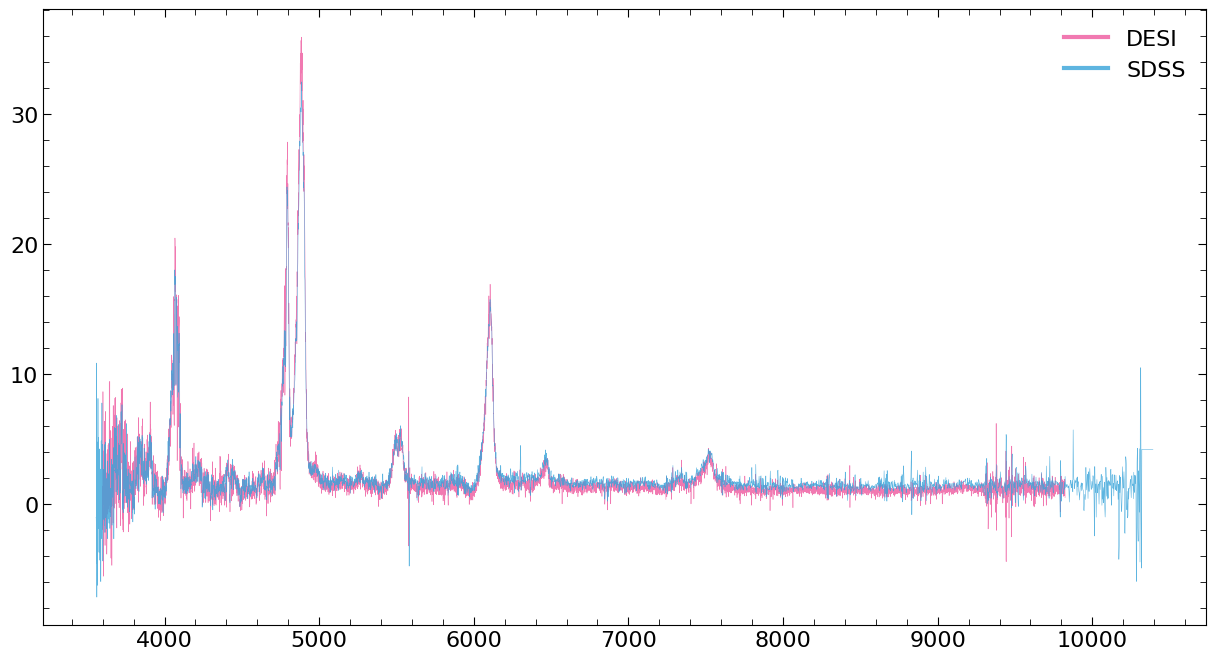

---------------------------------------
---------------------------------------

SDSS: J165202.64+172852.3


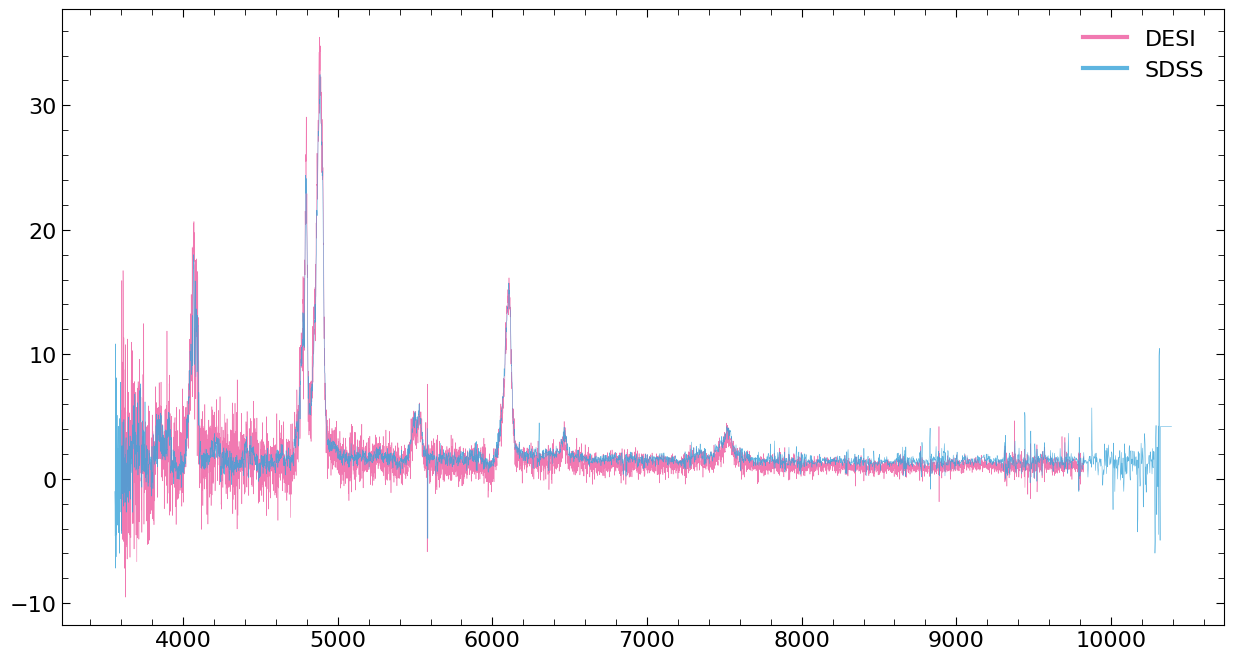

---------------------------------------
---------------------------------------

SDSS: J000746.19+122223.9


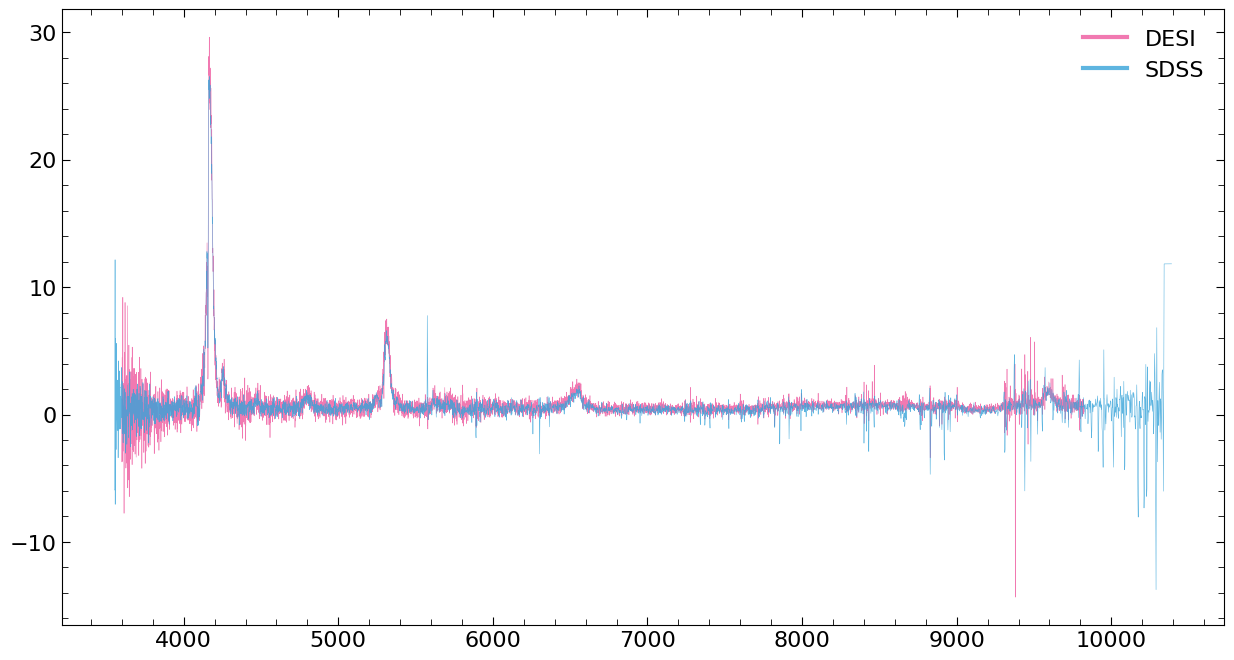

---------------------------------------
---------------------------------------

SDSS: J232326.17-010033.1


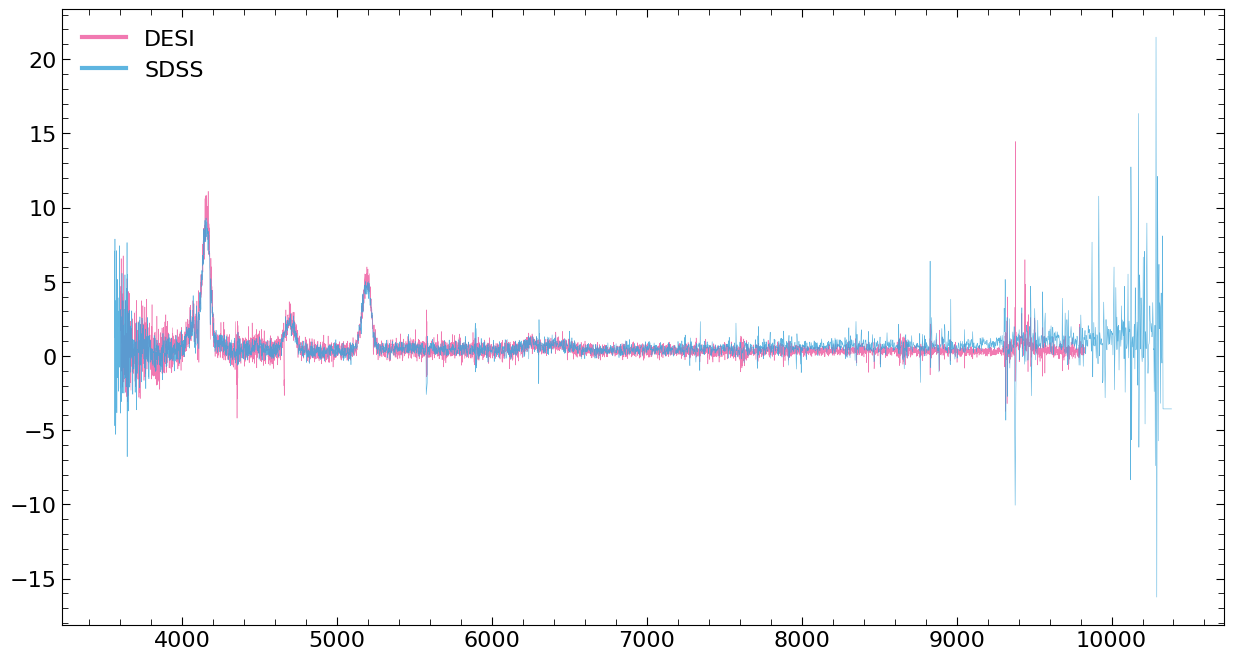

---------------------------------------
---------------------------------------

SDSS: J000610.67+121501.2


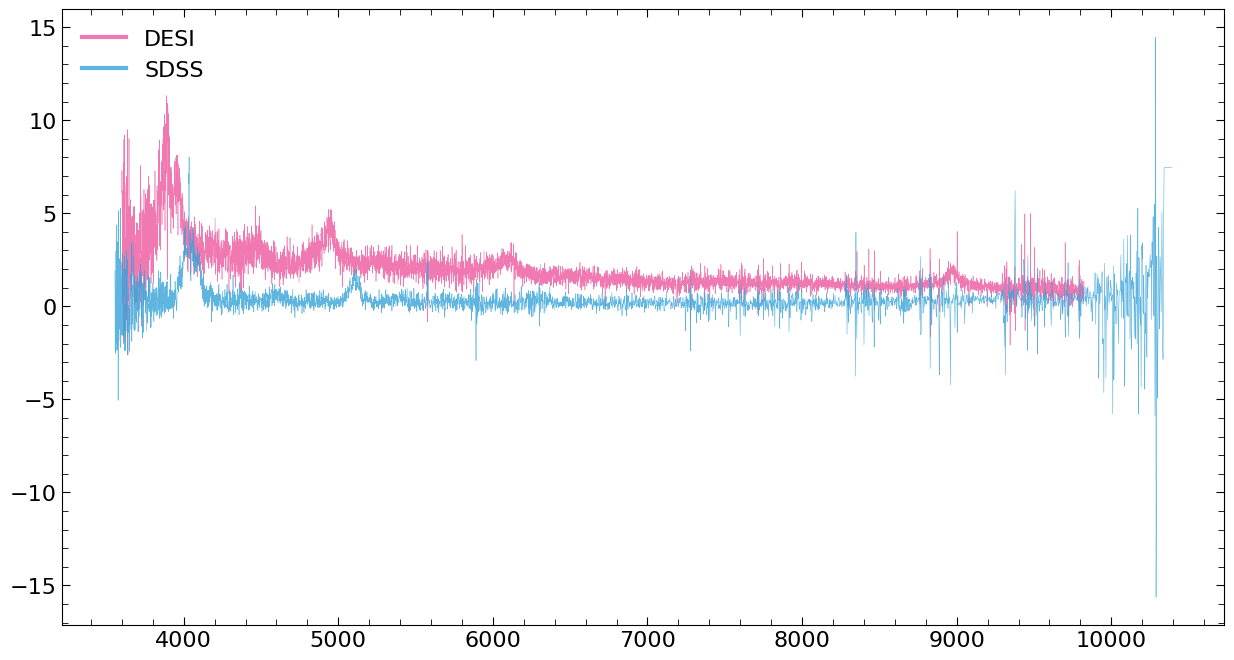

---------------------------------------
---------------------------------------

SDSS: J153107.14+105825.8


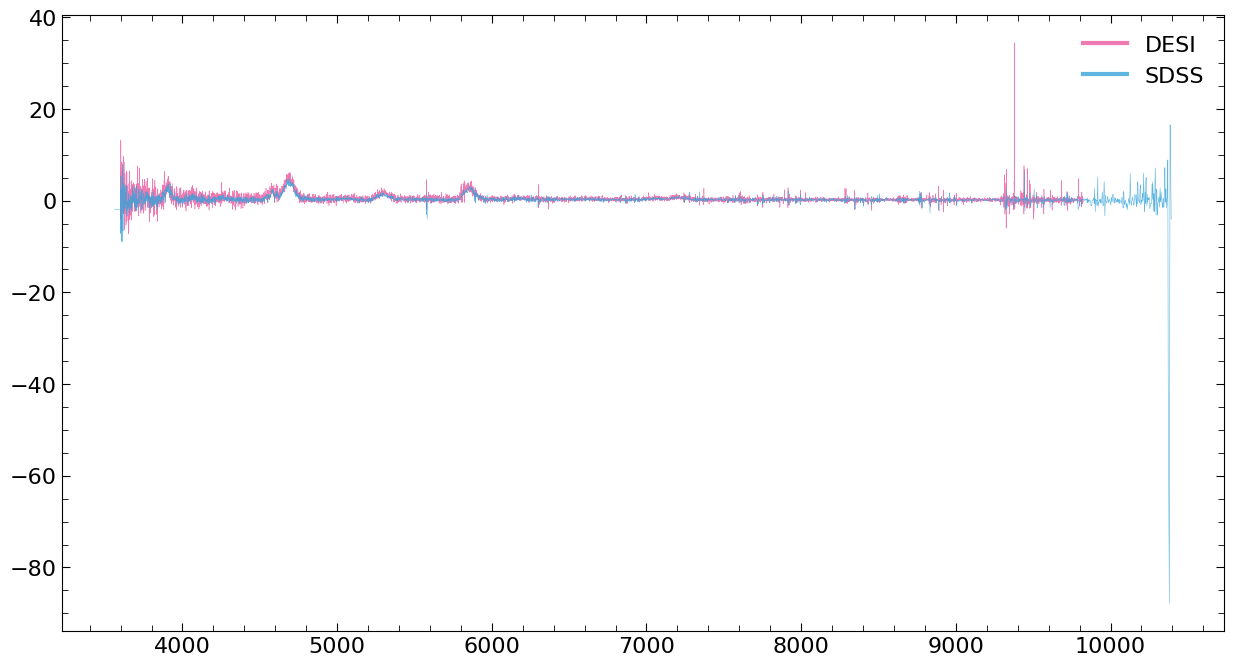

---------------------------------------
---------------------------------------

SDSS: J084447.66+462338.7


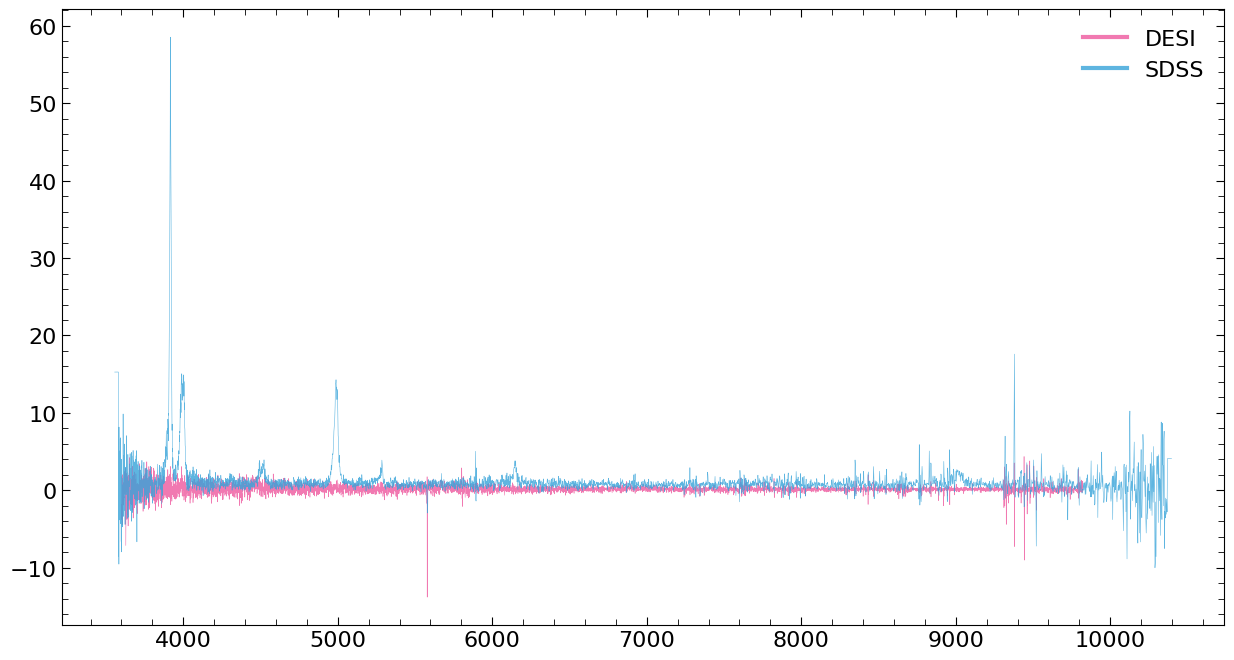

---------------------------------------
---------------------------------------

SDSS: J135608.32+073017.2


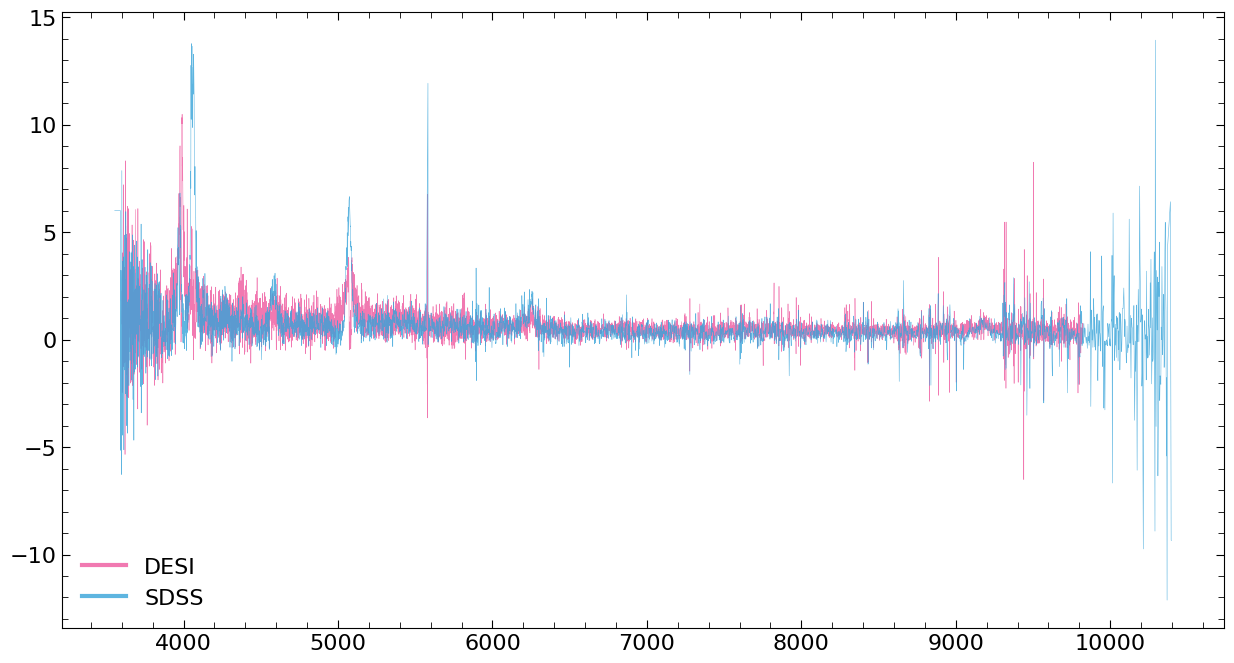

---------------------------------------
---------------------------------------

SDSS: J131722.85+322207.5


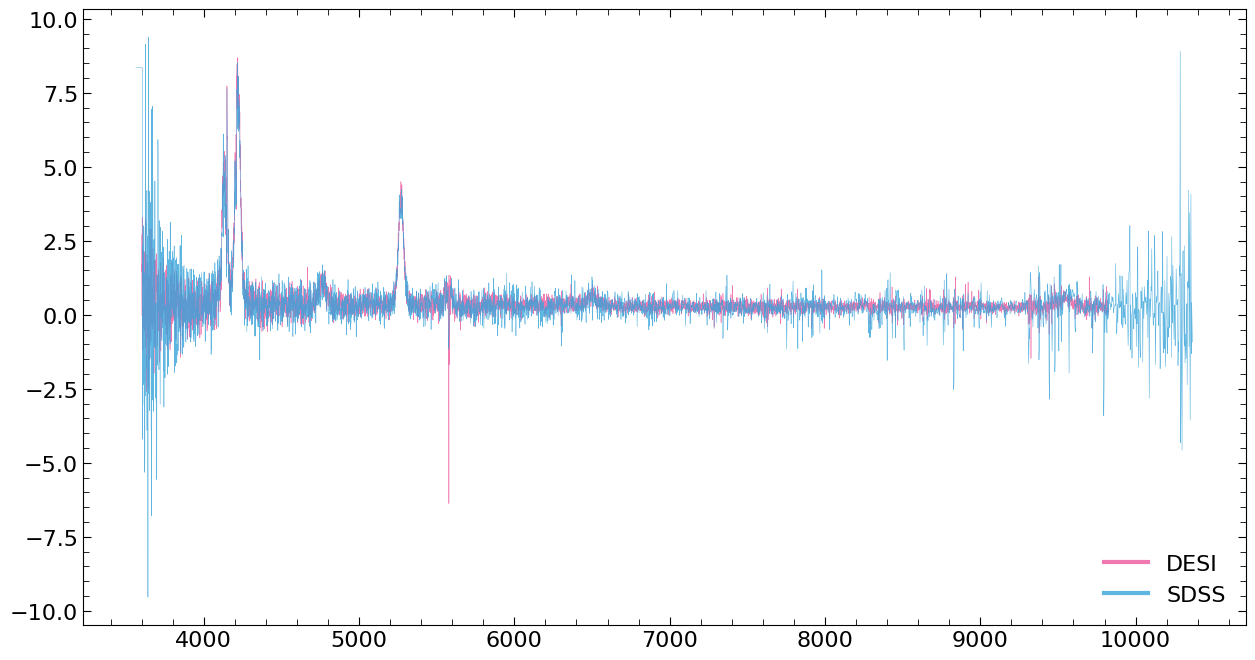

---------------------------------------
---------------------------------------

SDSS: J093638.41+101930.3


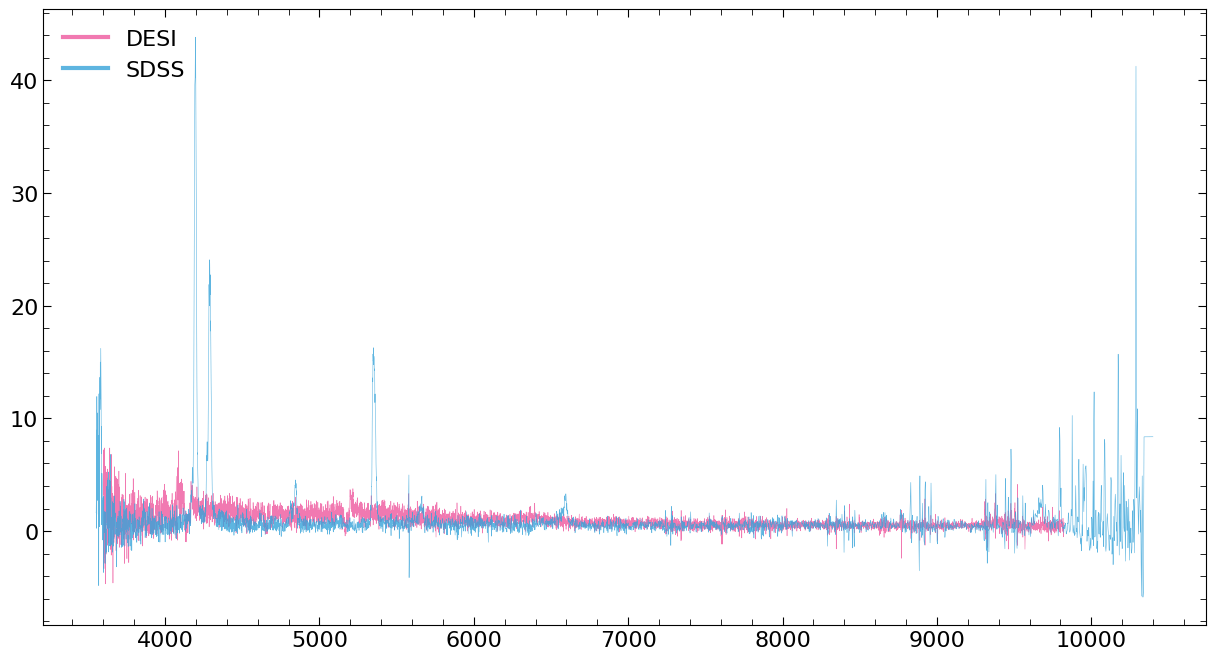

---------------------------------------
---------------------------------------

SDSS: J104718.35+484433.8


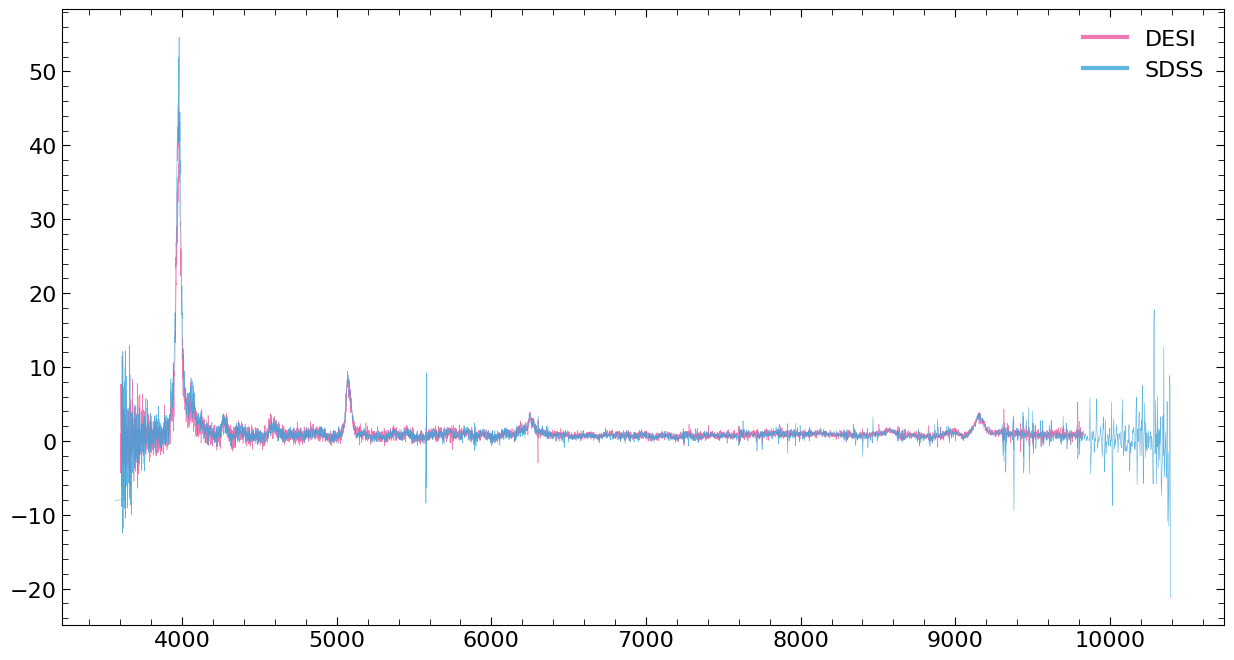

---------------------------------------
---------------------------------------

SDSS: J170558.64+273624.7


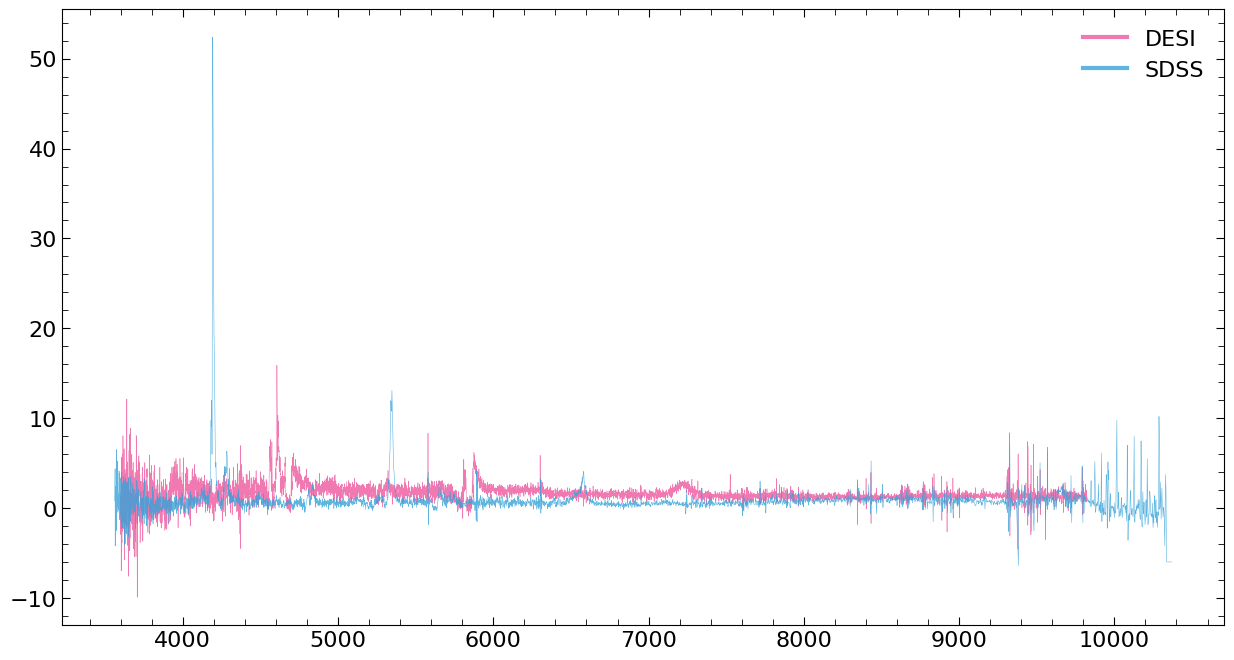

---------------------------------------
---------------------------------------

SDSS: J102541.78+245424.2


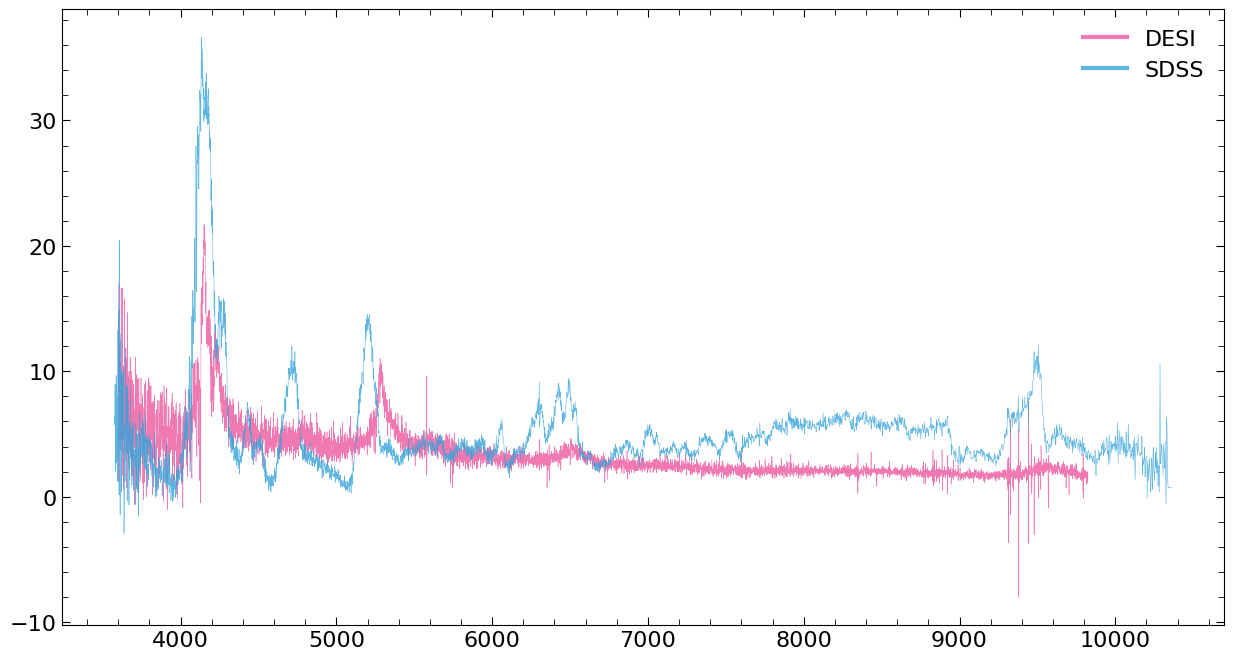

---------------------------------------
---------------------------------------

SDSS: J221524.00-005643.8


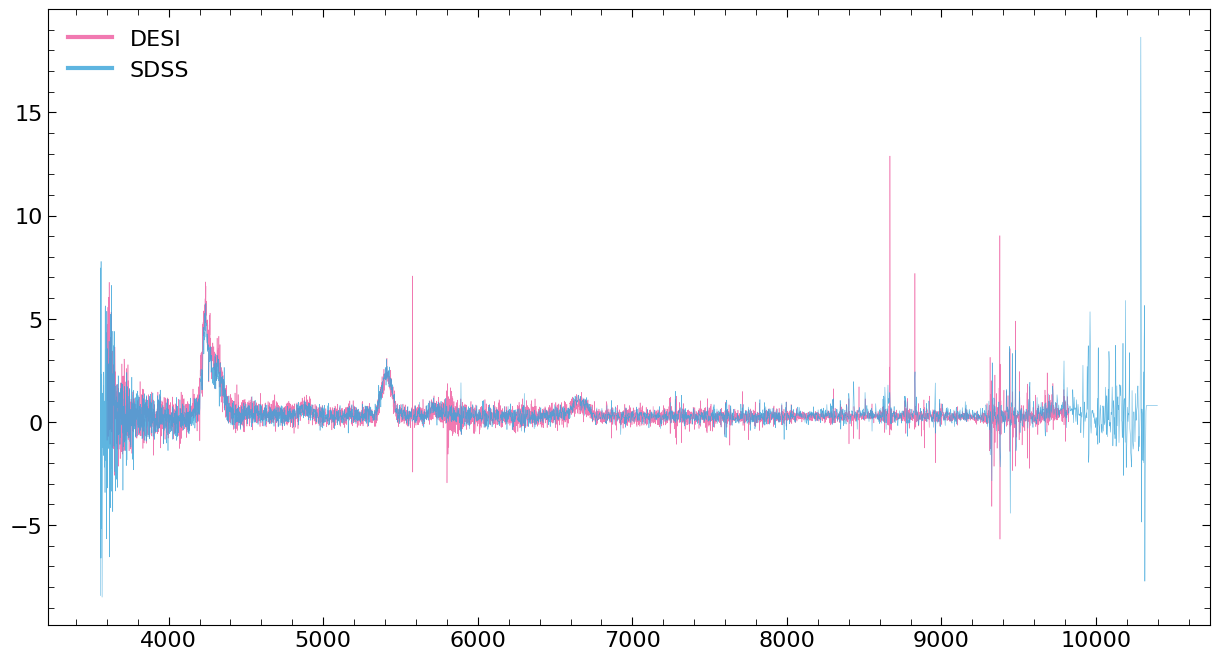

In [66]:
for i in range(len(spectra_combined)):
    desi_lam = spectra_combined["wavelength_desi"][i]
    desi_flux = spectra_combined["flux_desi"][i]
    sdss_lam = spectra_combined["wavelength_sdss"][i]
    sdss_flux = spectra_combined["flux_sdss"][i]
    sdss_id = spectra_combined["SDSS_id"][i]

    print(f"---------------------------------------\n---------------------------------------\n\nSDSS: {sdss_id}")


    plt.subplots(figsize=(15,8))

    plt.plot(desi_lam, desi_flux, color=palette_dark[0], linewidth=0.4, alpha=0.8, label="DESI")
    plt.plot(sdss_lam, sdss_flux, color=palette_dark[2], linewidth=0.4, alpha=0.8, label="SDSS")

    leg = plt.legend()

    for line in leg.get_lines():
        line.set_linewidth(3.0)

    plt.show()